In [1]:
import pandas as pd

# ================= 1. 读取数据 =================
# （保持你原有的代码不变）
ch0 = pd.read_csv("./compton_work_0525_27.5V/Cs137_work_60_60_60_40pt_27.5Vch0_mu_0525_5.5h_0cm_ch0.txt",sep="\t")
ch1 = pd.read_csv("./compton_work_0525_27.5V/Cs137_work_60_60_60_40pt_27.5Vch0_mu_0525_5.5h_0cm_ch1.txt",sep="\t")
ch2 = pd.read_csv("./compton_work_0525_27.5V/Cs137_work_60_60_60_40pt_27.5Vch0_mu_0525_5.5h_0cm_ch2.txt",sep="\t")

bkg_ch0 = pd.read_csv("./compton_bkg_0523_27.5V_result/compton_bkg_100_100_100_27.5V_28.5V_28.5V_0523_10h_ch0.txt",sep="\t")
bkg_ch1 = pd.read_csv("./compton_bkg_0523_27.5V_result/compton_bkg_100_100_100_27.5V_28.5V_28.5V_0523_10h_ch1.txt",sep="\t")
bkg_ch2 = pd.read_csv("./compton_bkg_0523_27.5V_result/compton_bkg_100_100_100_27.5V_28.5V_28.5V_0523_10h_ch2.txt",sep="\t")

energy_response_ch0 = pd.read_csv("./calib_result_27.5V/calibration_results_fixed_ch0/calibration_results.txt",sep="\t")
energy_response_ch1 = pd.read_csv("./Calib_28.5V_new_firmware_40pt_0513/calibration_results_fixed_ch1/calibration_results.txt",sep="\t")
energy_response_ch2 = pd.read_csv("./Calib_28.5V_new_firmware_40pt_0513/calibration_results_fixed_ch2/calibration_results.txt",sep="\t")

# ================= 2. 定义处理单通道数据的函数 =================
def process_channel(df_raw, df_calib, prefix):
    # 如果背景数据中列名不一样，可以用相同的逻辑处理
    merged = pd.merge(df_raw, df_calib[['PixelID', 'a(keV/ADC)', 'b(keV)']], 
                      on='PixelID', how='left')
    merged['energy_keV'] = merged['TotalEnergy'] * merged['a(keV/ADC)'] + merged['b(keV)']
    merged['energy_MeV'] = merged['energy_keV'] / 1000.0
    
    merged = merged.rename(columns={
        'PixelID': f'{prefix}_pixelid',
        'pos_x_mm': f'{prefix}_x',
        'pos_y_mm': f'{prefix}_y',
        'z': f'{prefix}_z',
        'energy_MeV': f'{prefix}_energy'
    })
    
    cols_to_keep = ['EventID', f'{prefix}_pixelid', f'{prefix}_x', f'{prefix}_y', f'{prefix}_z', f'{prefix}_energy']
    return merged[cols_to_keep]

# ================= 3. 对每个通道进行刻度转换 =================
df0_processed = process_channel(ch0, energy_response_ch0, 'ch0')
df1_processed = process_channel(ch1, energy_response_ch1, 'ch1')
df2_processed = process_channel(ch2, energy_response_ch2, 'ch2')

df_bkg_ch0 = process_channel(bkg_ch0, energy_response_ch0, 'bkg_ch0')
df_bkg_ch1 = process_channel(bkg_ch1, energy_response_ch1, 'bkg_ch1')
df_bkg_ch2 = process_channel(bkg_ch2, energy_response_ch2, 'bkg_ch2')

# ================= 4. 按 EventID 合并所有信号通道 =================
final_df = pd.merge(df0_processed, df1_processed, on='EventID', how='outer')
final_df = pd.merge(final_df, df2_processed, on='EventID', how='outer')
final_df = final_df.sort_values(by='EventID').reset_index(drop=True)

# ================= 5. 按 EventID 合并所有本底通道 =================
final_bkg_df = pd.merge(df_bkg_ch0, df_bkg_ch1, on='EventID', how='outer')
final_bkg_df = pd.merge(final_bkg_df, df_bkg_ch2, on='EventID', how='outer')
final_bkg_df = final_bkg_df.sort_values(by='EventID').reset_index(drop=True)

# ================= 6. 生成 rate_signal 和 rate_bkg =================
# 将时间转换为秒 (s)，以便计算 counts per second (cps)
time_bkg_sec = 589 * 60 
time_work_sec = 5.5*60 * 60 

# 复制合并好的完整 DataFrame
rate_signal = final_df.copy()
rate_bkg = final_bkg_df.copy()

# 为每个事件增加一列 'rate_cps' (权重)
# 每个事件代表 1 个 count，所以对应的率为 1 / 探测时间
rate_signal['rate_cps'] = 1.0 / time_work_sec
rate_bkg['rate_cps'] = 1.0 / time_bkg_sec

# 打印查看最终结果
print("--- Signal Rate DataFrame ---")
print(rate_signal.head())

print("\n--- Background Rate DataFrame ---")
print(rate_bkg.head())

--- Signal Rate DataFrame ---
    EventID  ch0_pixelid  ch0_x  ch0_y  ch0_z  ch0_energy  ch1_pixelid  ch1_x  \
0   5750267            0    0.0    0.0  -61.5         NaN           64   1.68   
1   8801522            0    0.0    0.0  -61.5         NaN          103  -8.40   
2  11042937            0    0.0    0.0  -61.5         NaN          183 -21.84   
3  12296872            0    0.0    0.0  -61.5         NaN           94   8.40   
4  16427112            0    0.0    0.0  -61.5         NaN           17 -15.12   

   ch1_y  ch1_z  ch1_energy  ch2_pixelid  ch2_x  ch2_y  ch2_z  ch2_energy  \
0  -8.40    -25    0.041337           10   8.40 -21.84      0    0.393482   
1   1.68    -25    0.461609          115 -15.12   5.04      0    0.205541   
2  21.84    -25    0.136023           36   1.68 -15.12      0    0.240420   
3  -1.68    -25    0.226411          192   8.40  21.84      0    0.462375   
4 -18.48    -25    0.072050          117  -8.40   5.04      0    0.170470   

   rate_cps  
0  0.0

In [3]:
##因为ch1和ch2 的adc有负数的
print(final_df[final_df['ch2_energy'].isnull()][['EventID', 'ch2_energy']])
# print(final_df)


              EventID  ch2_energy
121         525539531         NaN
5166      26188449610         NaN
5369      27230510273         NaN
6506      32803634509         NaN
11868     59647493398         NaN
...               ...         ...
433413  2170052979436         NaN
439375  2199968028869         NaN
441166  2208493755856         NaN
452441  2264750376993         NaN
481352  2409885657792         NaN

[82 rows x 2 columns]


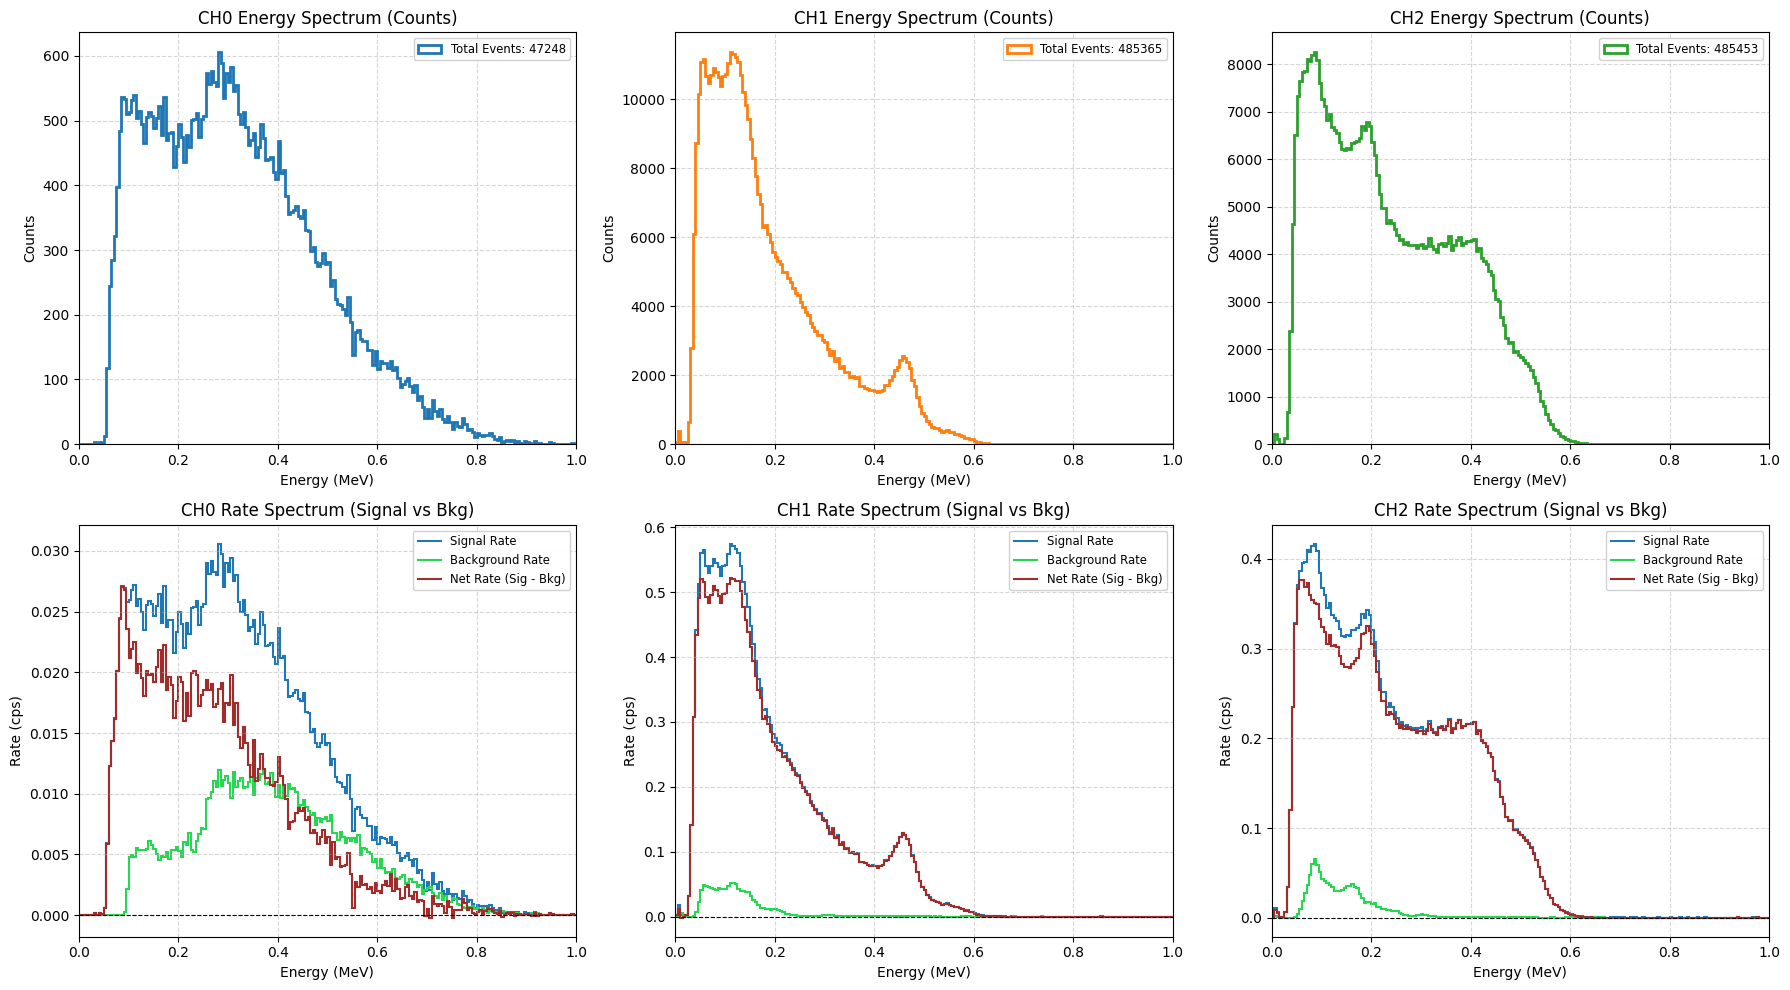

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. 定义高斯函数 (用于 0.662 MeV 峰拟合)
def gauss(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# 2. 设置画布布局: 2行3列 (Row 1: Counts, Row 2: Rate)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
channels = ['ch0', 'ch1', 'ch2']
# Counts 图使用的各通道颜色
counts_colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

# 定义拟合区间 (围绕 Cs-137 的 0.662 MeV 峰)
fit_min = 0.60
fit_max = 0.72

# 绘制能谱的范围和 bin 数量
plot_min = 0
plot_max = 1.0
n_bins = 200

for i, ch in enumerate(channels):
    # ==========================================
    # 第一行：原始 Counts 图 (仅信号)
    # ==========================================
    ax_counts = axes[0, i]
    
    # 提取当前通道能量数据，去除 NaN 以及 0 能量事件
    energy_data = final_df[f'{ch}_energy'].dropna()
    energy_data = energy_data[energy_data > 0]
    total_events = len(energy_data)
    
    # 绘制原始直方图
    counts_raw, bin_edges, _ = ax_counts.hist(
        energy_data, bins=n_bins, range=(plot_min, plot_max), 
        color=counts_colors[i], alpha=1, linewidth=2, histtype="step", 
        label=f'Total Events: {total_events}'
    )

            
    # Counts 图细节美化
    ax_counts.set_title(f'{ch.upper()} Energy Spectrum (Counts)')
    ax_counts.set_xlabel('Energy (MeV)')
    ax_counts.set_ylabel('Counts')
    ax_counts.set_xlim(plot_min, plot_max)
    ax_counts.legend(loc='upper right', framealpha=0.9, fontsize='small')
    ax_counts.grid(True, linestyle='--', alpha=0.5)


    # ==========================================
    # 第二行：Rate 及其相减图 (Signal, Background, Net)
    # ==========================================
    ax_rate = axes[1, i]
    
    # 提取信号数据与权重
    mask_sig = rate_signal[f'{ch}_energy'].notna() & (rate_signal[f'{ch}_energy'] > 0)
    sig_energy = rate_signal.loc[mask_sig, f'{ch}_energy']
    sig_weights = rate_signal.loc[mask_sig, 'rate_cps']
    
    # 提取本底数据与权重
    mask_bkg = rate_bkg[f'bkg_{ch}_energy'].notna() & (rate_bkg[f'bkg_{ch}_energy'] > 0)
    bkg_energy = rate_bkg.loc[mask_bkg, f'bkg_{ch}_energy']
    bkg_weights = rate_bkg.loc[mask_bkg, 'rate_cps']
    
    # 计算每个 bin 的 Rate
    counts_sig, _ = np.histogram(sig_energy, bins=n_bins, range=(plot_min, plot_max), weights=sig_weights)
    counts_bkg, _ = np.histogram(bkg_energy, bins=n_bins, range=(plot_min, plot_max), weights=bkg_weights)
    
    # 计算净计数率 (Net Rate)
    net_rate = counts_sig - counts_bkg
    
    # 绘制 Rate 阶梯图
    ax_rate.stairs(counts_sig, bin_edges, color='#1f77b4', linewidth=1.5, label='Signal Rate')
    ax_rate.stairs(counts_bkg, bin_edges, color="#27d653", linewidth=1.5, label='Background Rate')
    ax_rate.stairs(net_rate, bin_edges, color="#a02c2c", linewidth=1.5, fill=False, alpha=1, label='Net Rate (Sig - Bkg)')
    

    # Rate 图细节美化
    ax_rate.set_title(f'{ch.upper()} Rate Spectrum (Signal vs Bkg)')
    ax_rate.set_xlabel('Energy (MeV)')
    ax_rate.set_ylabel('Rate (cps)')
    ax_rate.set_xlim(plot_min, plot_max)
    ax_rate.axhline(0, color='black', linewidth=0.8, linestyle='--') # 加一条 y=0 的水平参考线
    ax_rate.legend(loc='upper right', framealpha=0.9, fontsize='small')
    ax_rate.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

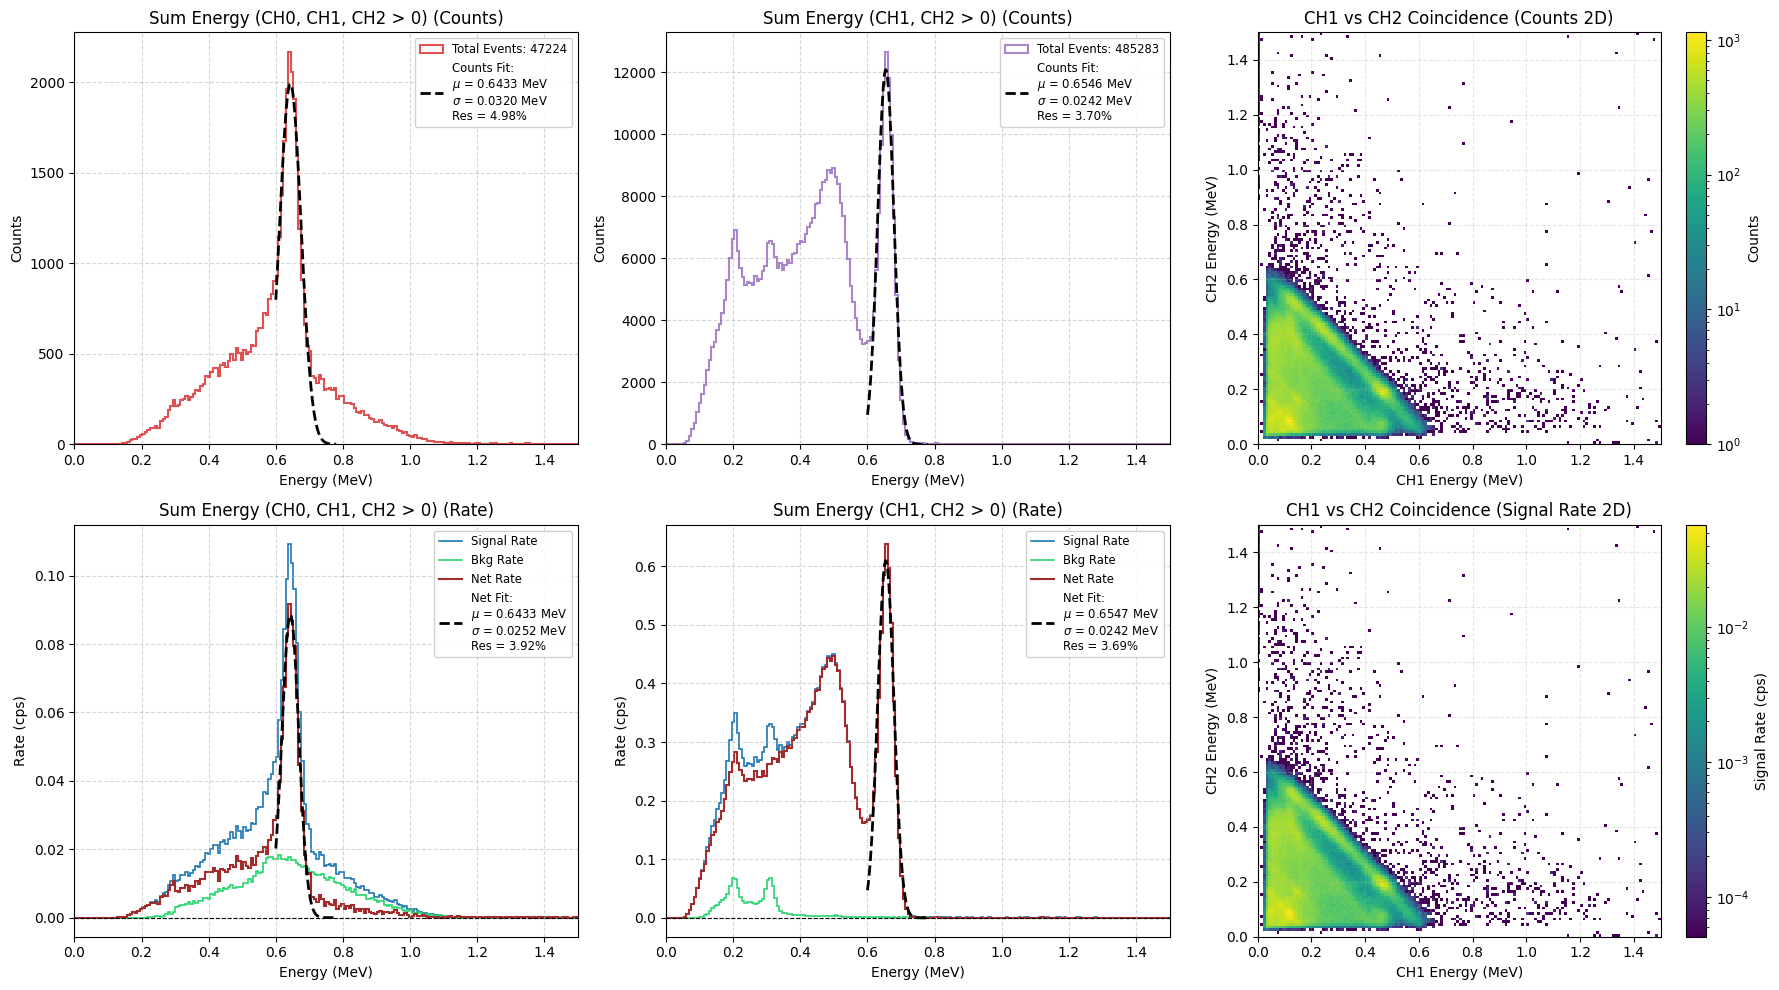

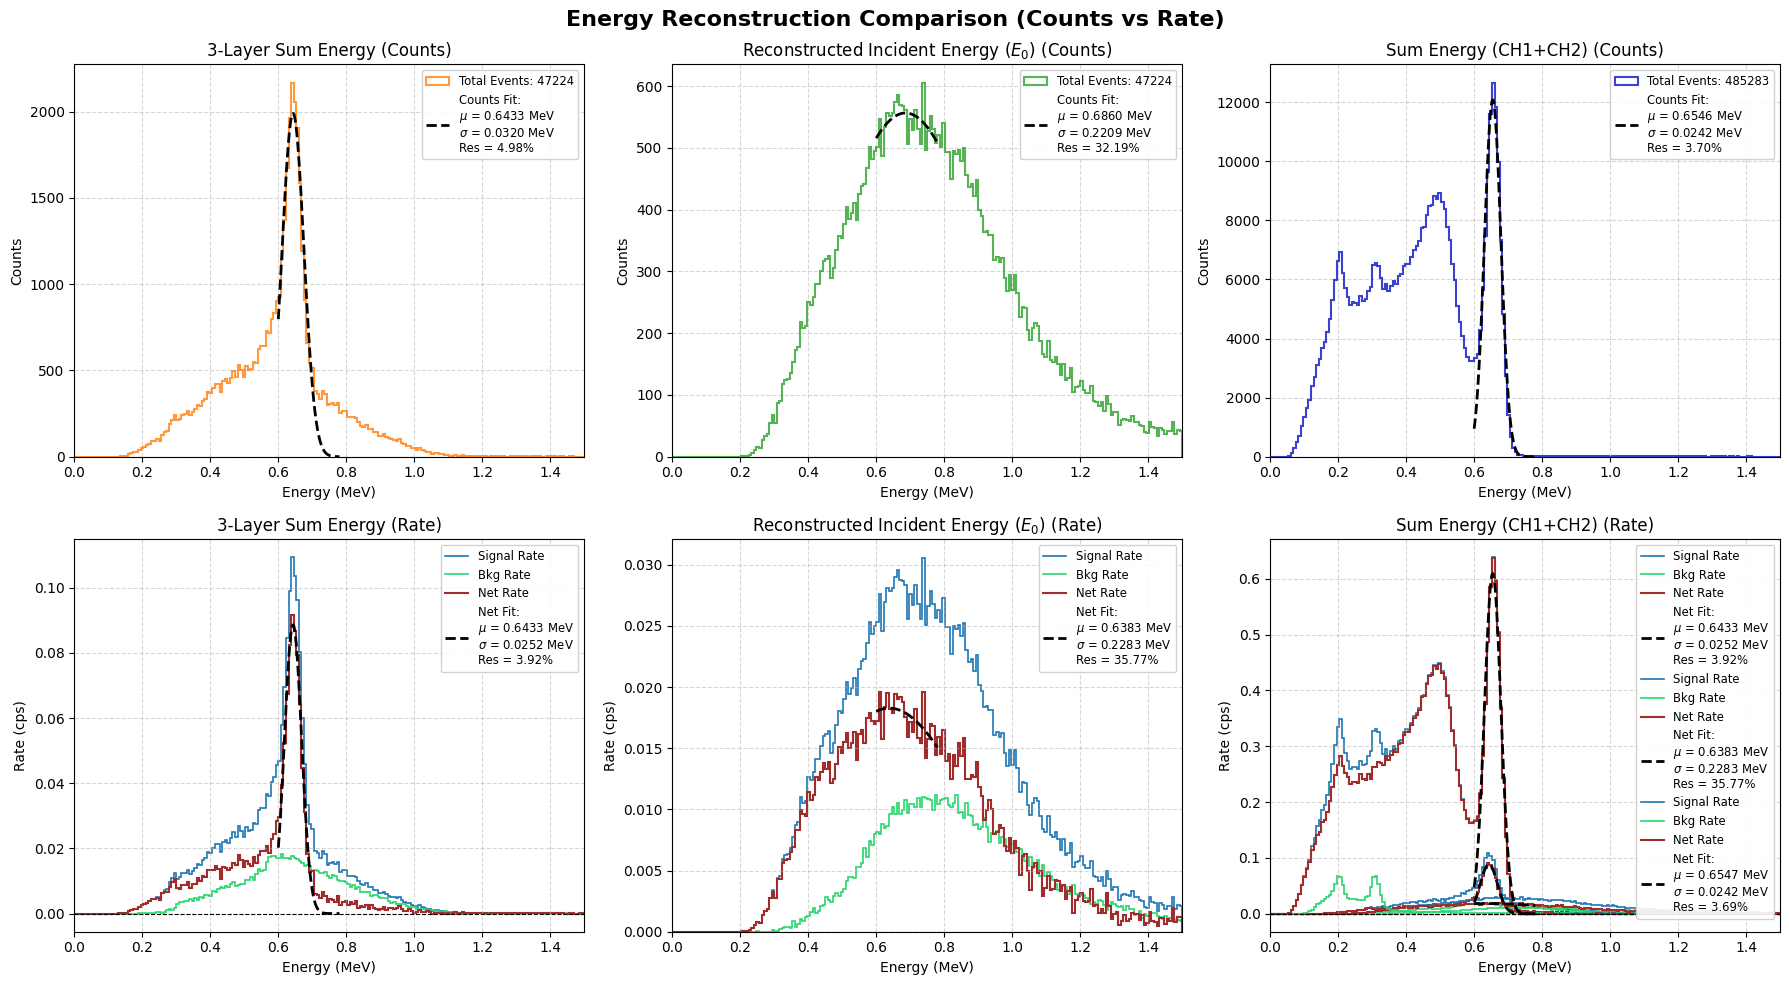

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

# ================= 1. 定义高斯函数 =================
def gauss(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# ================= 2. 准备数据与掩码 (分别处理 Signal 和 Background) =================

# --- 信号数据 (Signal) ---
e_ch0_sig = rate_signal['ch0_energy'].fillna(0)
e_ch1_sig = rate_signal['ch1_energy'].fillna(0)
e_ch2_sig = rate_signal['ch2_energy'].fillna(0)
w_sig = rate_signal['rate_cps']

mask_all3_sig = (e_ch0_sig > 0) & (e_ch1_sig > 0) & (e_ch2_sig > 0)
e_sum_all_sig = (e_ch0_sig + e_ch1_sig + e_ch2_sig)[mask_all3_sig]
w_all3_sig = w_sig[mask_all3_sig]

mask_12_sig = (e_ch1_sig > 0) & (e_ch2_sig > 0) 
e_sum_12_sig = (e_ch1_sig + e_ch2_sig)[mask_12_sig]
w_12_sig = w_sig[mask_12_sig]

# --- 本底数据 (Background) ---
e_ch0_bkg = rate_bkg['bkg_ch0_energy'].fillna(0)
e_ch1_bkg = rate_bkg['bkg_ch1_energy'].fillna(0)
e_ch2_bkg = rate_bkg['bkg_ch2_energy'].fillna(0)
w_bkg = rate_bkg['rate_cps']

mask_all3_bkg = (e_ch0_bkg > 0) & (e_ch1_bkg > 0) & (e_ch2_bkg > 0)
e_sum_all_bkg = (e_ch0_bkg + e_ch1_bkg + e_ch2_bkg)[mask_all3_bkg]
w_all3_bkg = w_bkg[mask_all3_bkg]

mask_12_bkg = (e_ch1_bkg > 0) & (e_ch2_bkg > 0)
e_sum_12_bkg = (e_ch1_bkg + e_ch2_bkg)[mask_12_bkg]
w_12_bkg = w_bkg[mask_12_bkg]


# ================= 3. 定义两套绘图与拟合函数 (Counts 和 Rate) =================
plot_min, plot_max = 0.0, 1.5
n_bins = 200
fit_min, fit_max = 0.60, 0.78

def plot_counts_and_fit(ax, data, title, color):
    """绘制纯信号的 Counts 直方图及高斯拟合"""
    total_events = len(data)
    counts, bin_edges, _ = ax.hist(data, bins=n_bins, range=(plot_min, plot_max), 
                                   color=color, alpha=0.8, histtype="step", linewidth=1.5,
                                   label=f'Total Events: {total_events}')
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    mask = (bin_centers >= fit_min) & (bin_centers <= fit_max)
    x_fit, y_fit = bin_centers[mask], counts[mask]
    
    if len(x_fit) > 0 and max(y_fit) > 0:
        p0 = [max(y_fit), 0.662, 0.02]
        try:
            popt, _ = curve_fit(gauss, x_fit, y_fit, p0=p0)
            a_opt, mu_opt, sigma_opt = popt
            sigma_opt = abs(sigma_opt)
            resolution = (sigma_opt / mu_opt) * 100
            x_plot = np.linspace(fit_min, fit_max, 100)
            
            fit_label = (f'Counts Fit:\n$\\mu$ = {mu_opt:.4f} MeV\n$\\sigma$ = {sigma_opt:.4f} MeV\nRes = {resolution:.2f}%')
            ax.plot(x_plot, gauss(x_plot, *popt), 'k--', linewidth=2, label=fit_label)
        except:
            pass
            
    ax.set_title(f"{title} (Counts)")
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Counts')
    ax.set_xlim(plot_min, plot_max)
    ax.legend(loc='upper right', framealpha=0.9, fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.5)

def plot_rate_and_fit(ax, data_sig, weight_sig, data_bkg, weight_bkg, title):
    """绘制信号、本底及净计数率的直方图，并对 Net Rate 进行拟合"""
    counts_sig, bin_edges = np.histogram(data_sig, bins=n_bins, range=(plot_min, plot_max), weights=weight_sig)
    counts_bkg, _ = np.histogram(data_bkg, bins=n_bins, range=(plot_min, plot_max), weights=weight_bkg)
    net_rate = counts_sig - counts_bkg
    
    ax.stairs(counts_sig, bin_edges, color='#1f77b4', linewidth=1.2, label='Signal Rate')
    ax.stairs(counts_bkg, bin_edges, color="#27d66d", linewidth=1.2, label='Bkg Rate')
    ax.stairs(net_rate, bin_edges, color="#a02c2c", linewidth=1.5, fill=False, alpha=1, label='Net Rate')
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    mask = (bin_centers >= fit_min) & (bin_centers <= fit_max)
    x_fit, y_fit = bin_centers[mask], net_rate[mask]
    
    if len(x_fit) > 0 and max(y_fit) > 0:
        p0 = [max(y_fit), 0.662, 0.02]
        try:
            popt, _ = curve_fit(gauss, x_fit, y_fit, p0=p0)
            a_opt, mu_opt, sigma_opt = popt
            sigma_opt = abs(sigma_opt)
            resolution = (sigma_opt / mu_opt) * 100
            x_plot = np.linspace(fit_min, fit_max, 100)
            
            fit_label = (f'Net Fit:\n$\\mu$ = {mu_opt:.4f} MeV\n$\\sigma$ = {sigma_opt:.4f} MeV\nRes = {resolution:.2f}%')
            ax.plot(x_plot, gauss(x_plot, *popt), 'k--', linewidth=2, label=fit_label)
        except:
            pass
            
    ax.set_title(f"{title} (Rate)")
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Rate (cps)')
    ax.set_xlim(plot_min, plot_max)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(loc='upper right', framealpha=0.9, fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.5)


# ================= 4. 绘制图一 (基础符合加和: 2行3列) =================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 第一行：Counts (纯信号)
plot_counts_and_fit(axes[0, 0], e_sum_all_sig, 'Sum Energy (CH0, CH1, CH2 > 0)', '#d62728')
plot_counts_and_fit(axes[0, 1], e_sum_12_sig, 'Sum Energy (CH1, CH2 > 0)', '#9467bd')

# 第一行：2D 亮度图 (Counts)
e_ch1_2d_sig = e_ch1_sig[mask_12_sig]
e_ch2_2d_sig = e_ch2_sig[mask_12_sig]
w_2d_sig = w_sig[mask_12_sig]

_, _, _, img_counts = axes[0, 2].hist2d(e_ch1_2d_sig, e_ch2_2d_sig, bins=150, 
                                        range=[[plot_min, plot_max], [plot_min, plot_max]], 
                                        cmap='viridis', cmin=1, norm=LogNorm())
fig.colorbar(img_counts, ax=axes[0, 2], label='Counts')
axes[0, 2].set_title('CH1 vs CH2 Coincidence (Counts 2D)')
axes[0, 2].set_xlabel('CH1 Energy (MeV)')
axes[0, 2].set_ylabel('CH2 Energy (MeV)')
axes[0, 2].grid(True, linestyle='--', alpha=0.3)

# 第二行：Rate (信号/本底/净值)
plot_rate_and_fit(axes[1, 0], e_sum_all_sig, w_all3_sig, e_sum_all_bkg, w_all3_bkg, 'Sum Energy (CH0, CH1, CH2 > 0)')
plot_rate_and_fit(axes[1, 1], e_sum_12_sig, w_12_sig, e_sum_12_bkg, w_12_bkg, 'Sum Energy (CH1, CH2 > 0)')

# 第二行：2D 亮度图 (Signal Rate)
_, _, _, img_rate = axes[1, 2].hist2d(e_ch1_2d_sig, e_ch2_2d_sig, bins=150, weights=w_2d_sig,
                                      range=[[plot_min, plot_max], [plot_min, plot_max]], 
                                      cmap='viridis', cmin=1e-6, norm=LogNorm())
fig.colorbar(img_rate, ax=axes[1, 2], label='Signal Rate (cps)')
axes[1, 2].set_title('CH1 vs CH2 Coincidence (Signal Rate 2D)')
axes[1, 2].set_xlabel('CH1 Energy (MeV)')
axes[1, 2].set_ylabel('CH2 Energy (MeV)')
axes[1, 2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


# ================= 5. 定义运动学反推函数并应用 =================
def reconstruct_E0(df, mask, pos_prefix, energy_prefix):
    """提取有效事件并进行运动学重建"""
    p1_x, p1_y, p1_z = df[f'{pos_prefix}ch0_x'][mask].values, df[f'{pos_prefix}ch0_y'][mask].values, df[f'{pos_prefix}ch0_z'][mask].values
    p2_x, p2_y, p2_z = df[f'{pos_prefix}ch1_x'][mask].values, df[f'{pos_prefix}ch1_y'][mask].values, df[f'{pos_prefix}ch1_z'][mask].values
    p3_x, p3_y, p3_z = df[f'{pos_prefix}ch2_x'][mask].values, df[f'{pos_prefix}ch2_y'][mask].values, df[f'{pos_prefix}ch2_z'][mask].values

    v1_x, v1_y, v1_z = p2_x - p1_x, p2_y - p1_y, p2_z - p1_z
    v2_x, v2_y, v2_z = p3_x - p2_x, p3_y - p2_y, p3_z - p2_z

    dot_product = v1_x*v2_x + v1_y*v2_y + v1_z*v2_z
    norm_v1 = np.sqrt(v1_x**2 + v1_y**2 + v1_z**2)
    norm_v2 = np.sqrt(v2_x**2 + v2_y**2 + v2_z**2)

    valid_norm_mask = (norm_v1 > 0) & (norm_v2 > 0)
    cos_theta2 = np.zeros_like(dot_product)
    cos_theta2[valid_norm_mask] = dot_product[valid_norm_mask] / (norm_v1[valid_norm_mask] * norm_v2[valid_norm_mask])

    dE1 = df[f'{energy_prefix}ch0_energy'][mask].values
    dE2 = df[f'{energy_prefix}ch1_energy'][mask].values
    m_e_c2 = 0.511

    valid_angle_mask = (1 - cos_theta2) > 1e-5

    E0_reconstructed = np.zeros_like(dE1)
    term_under_sqrt = dE2[valid_angle_mask]**2 + 4 * dE2[valid_angle_mask] * m_e_c2 / (1 - cos_theta2[valid_angle_mask])
    term_sqrt = np.sqrt(np.maximum(term_under_sqrt, 0))
    E0_reconstructed[valid_angle_mask] = dE1[valid_angle_mask] + (dE2[valid_angle_mask] + term_sqrt) / 2

    final_valid_mask = valid_norm_mask & valid_angle_mask & (E0_reconstructed > 0)
    return E0_reconstructed[final_valid_mask], final_valid_mask

# --- 对 Signal 和 Background 进行运动学重建 ---
E0_sig, valid_mask_sig = reconstruct_E0(rate_signal, mask_all3_sig, pos_prefix='', energy_prefix='')
final_w_sig = w_all3_sig.values[valid_mask_sig]
final_esum_sig = e_sum_all_sig.values[valid_mask_sig]

E0_bkg, valid_mask_bkg = reconstruct_E0(rate_bkg, mask_all3_bkg, pos_prefix='bkg_', energy_prefix='bkg_')
final_w_bkg = w_all3_bkg.values[valid_mask_bkg]
final_esum_bkg = e_sum_all_bkg.values[valid_mask_bkg]


# ================= 6. 绘制图二 (运动学重建对比: 2行3列) =================
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))

# 第一行：Counts (纯信号)
plot_counts_and_fit(axes2[0, 0], final_esum_sig, '3-Layer Sum Energy', '#ff7f0e')
plot_counts_and_fit(axes2[0, 1], E0_sig, 'Reconstructed Incident Energy ($E_0$)', '#2ca02c')
plot_counts_and_fit(axes2[0, 2], e_sum_12_sig, 'Sum Energy (CH1+CH2)', '#0a13c4')

# 第二行：Rate (信号/本底/净值)
plot_rate_and_fit(axes2[1, 0], final_esum_sig, final_w_sig, final_esum_bkg, final_w_bkg, '3-Layer Sum Energy')
plot_rate_and_fit(axes2[1, 1], E0_sig, final_w_sig, E0_bkg, final_w_bkg, 'Reconstructed Incident Energy ($E_0$)')
plot_rate_and_fit(axes2[1, 2], final_esum_sig, final_w_sig, final_esum_bkg, final_w_bkg, '3-Layer Sum Energy')
plot_rate_and_fit(axes2[1, 2], E0_sig, final_w_sig, E0_bkg, final_w_bkg, 'Reconstructed Incident Energy ($E_0$)')
plot_rate_and_fit(axes2[1, 2], e_sum_12_sig, w_12_sig, e_sum_12_bkg, w_12_bkg, 'Sum Energy (CH1+CH2)')

plt.suptitle("Energy Reconstruction Comparison (Counts vs Rate)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

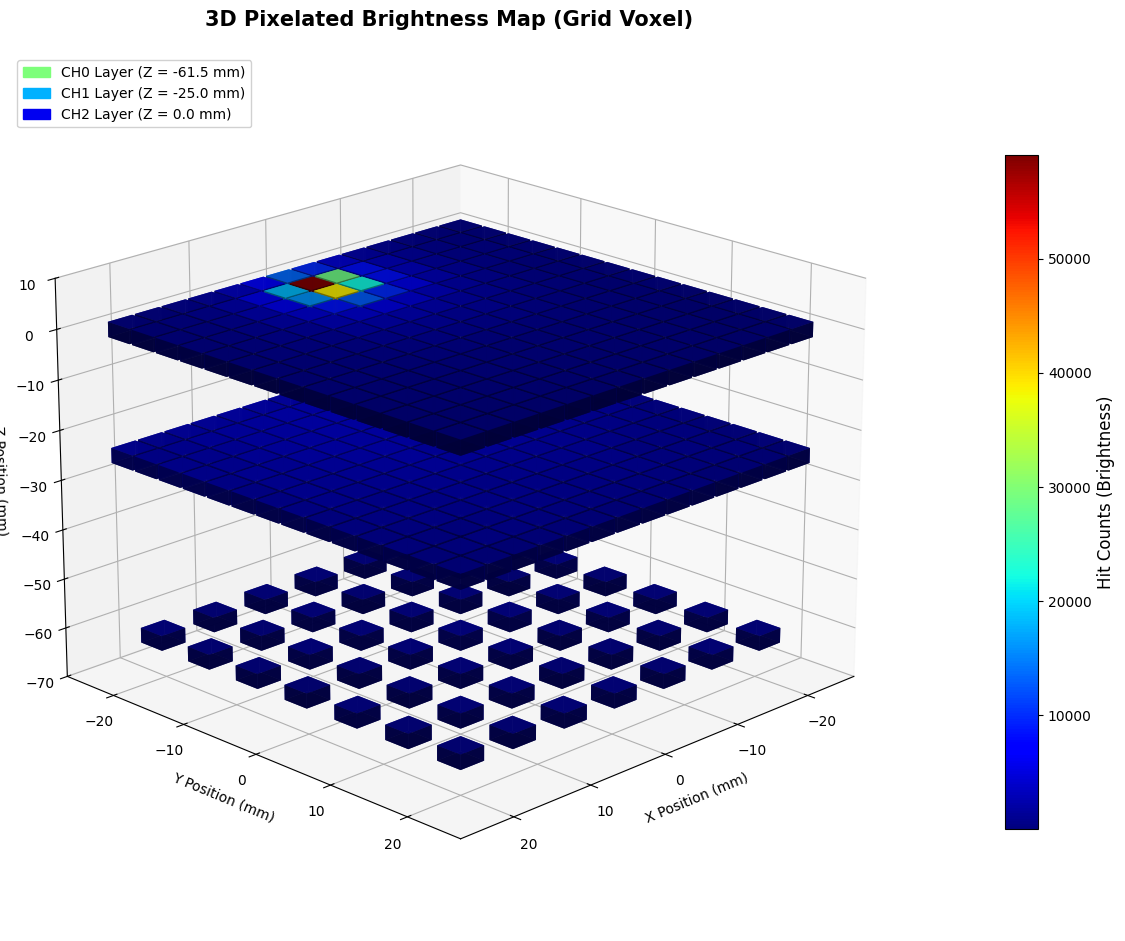

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# 1. 定义探测器真实的物理 Z 坐标映射
true_z_map = {
    'ch0': -61.5,
    'ch1': -25.0,
    'ch2': 0.0
}

# 创建 3D 画布
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

channels = ['ch0', 'ch1', 'ch2']
global_max_count = 1
pixel_data_list = []

# 2. 提取非空像素并计算亮度 (计数)
for i, ch in enumerate(channels):
    # 筛选有效事件 (能量 > 0)
    mask = final_df[f'{ch}_energy'] > 0
    df_valid = final_df[mask]
    
    if not df_valid.empty:
        # 按 x, y 分组统计
        pixel_counts = df_valid.groupby([f'{ch}_x', f'{ch}_y']).size().reset_index(name='counts')
        pixel_data_list.append(pixel_counts)
        global_max_count = max(global_max_count, pixel_counts['counts'].max())
    else:
        pixel_data_list.append(None)

# ================= 核心修改区：准备颜色与像素几何尺寸 =================

# 设置颜色映射器 (ScalarMappable)
cmap = plt.get_cmap('jet')
norm = mcolors.Normalize(vmin=1, vmax=global_max_count)

# 【重要参数】这里定义你探测器单个像素的长宽。
# 我根据常见的硅像素探测器预设了 1.5mm，请根据你实际的探测器 pixel pitch 进行修改！
pixel_dx = 3  # X方向像素宽度 (mm)
pixel_dy = 3  # Y方向像素宽度 (mm)
pixel_dz = 3  # 渲染出的像素块的厚度 (让它看起来像薄薄的一片)

# ====================================================================

# 3. 逐层绘制 3D 像素网格 (Voxel/Bar3D)
legend_patches = [] # 用于手动生成图例

for i, ch in enumerate(channels):
    pixel_counts = pixel_data_list[i]
    if pixel_counts is None or pixel_counts.empty:
        continue
        
    x_center = pixel_counts[f'{ch}_x'].values
    y_center = pixel_counts[f'{ch}_y'].values
    counts = pixel_counts['counts'].values
    
    real_z_val = true_z_map[ch]
    
    # bar3d 需要的是方块的“左下角”起始坐标，因此要用中心坐标减去尺寸的一半
    x_pos = x_center - pixel_dx / 2
    y_pos = y_center - pixel_dy / 2
    z_pos = np.full_like(x_center, real_z_val - pixel_dz / 2, dtype=float)
    
    # 每个方块的长、宽、高
    dx = np.full_like(x_center, pixel_dx, dtype=float)
    dy = np.full_like(x_center, pixel_dy, dtype=float)
    dz = np.full_like(x_center, pixel_dz, dtype=float)
    
    # 获取每个像素对应的颜色
    colors = cmap(norm(counts))
    
    # 画出 3D 像素块：shade=True 会开启 3D 光影质感，更有立体感
    ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color=colors, alpha=0.9, shade=True)
    
    # 为每一层创建一个图例色块 (因为 bar3d 不能像 scatter 那样直接传 label 参数)
    # 取 cmap(0.5) 也就是绿色作为图例的底色
    legend_patches.append(mpatches.Patch(color=cmap(0.5 - i*0.2), label=f'{ch.upper()} Layer (Z = {real_z_val} mm)'))

# 4. 图表美化与视角调整
ax.set_title("3D Pixelated Brightness Map (Grid Voxel)", fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel("X Position (mm)")
ax.set_ylabel("Y Position (mm)")
ax.set_zlabel("Z Position (mm)")

ax.set_zlim(-70, 10)
ax.view_init(elev=20, azim=45)

# 绑定手动生成的图例
ax.legend(handles=legend_patches, loc='upper left', fontsize=10, framealpha=0.9)

# 生成独立的 Colorbar (因为 bar3d 不返回 Mappable 对象，需要单独构建)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Hit Counts (Brightness)', fontsize=12)

plt.tight_layout()
plt.show()

1. 从 final_df 中提取事件顶点、轴线与张角...
处理的双/三击中事件总数: 485307
因未落在全能峰 (0.652, 0.672) MeV 被剔除的事件: 449442
有效物理事件总数: 25094，抽取 25094 个事件画圆环...
2. 在 Z = 1 mm 平面上生成圆环轨迹...
3. 绘制重叠圆环图像...


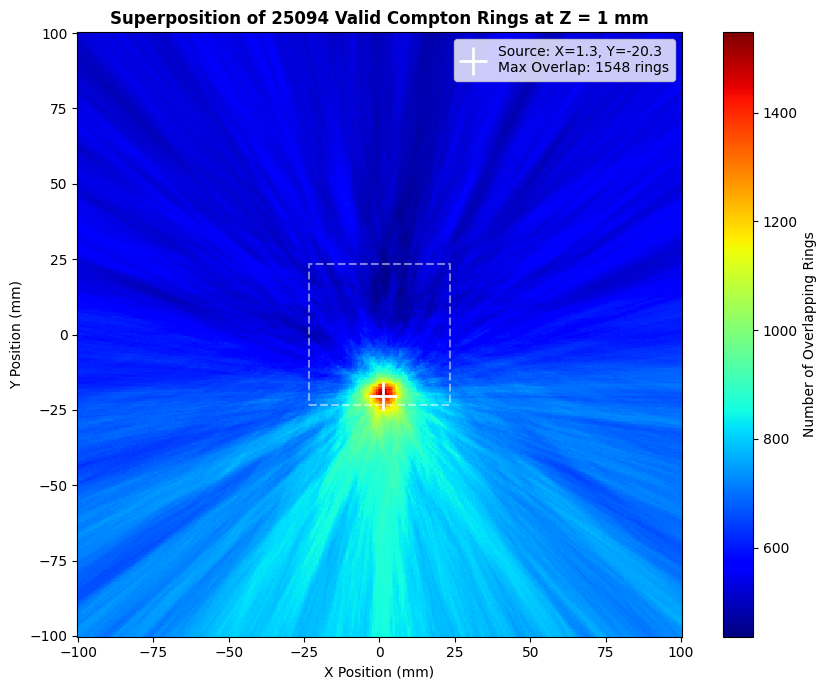

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##############此处将全吸收峰进行重建########
m_e = 0.511  # 电子静止质量 MeV

def reconstruct_overlapping_rings_from_df(df, Z_plane=50.0, resolution=400, fov=150.0, num_events=300, 
                                          energy_window=(0.60, 0.72)):
    print("1. 从 final_df 中提取事件顶点、轴线与张角...")
    
    r1_positions = []
    axes = []
    angles = []
    
    # 提取符合能量窗的事件数统计，方便你 Debug
    total_processed = 0
    energy_rejected = 0
    
    for row in df.itertuples(index=False):
        hits = []
        cols = df.columns
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if e_col in cols:
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    x = getattr(row, f'{ch}_x')
                    y = getattr(row, f'{ch}_y')
                    z = getattr(row, f'{ch}_z')
                    hits.append((x, y, z, e_val))
                    
        if len(hits) < 2:
            continue
            
        total_processed += 1
        E_total = sum(h[3] for h in hits)
        
        # ================== 核心修复 1：能量窗截断 ==================
        # 只有当总沉积能量位于全能峰(Photopeak)附近时，康普顿公式才成立！
        if not (energy_window[0] <= E_total <= energy_window[1]):
            energy_rejected += 1
            continue
            
        # ================== 核心修复 2：物理击中顺序 ==================
        # 假设放射源在前方 (Z > 0)，光子会先击中 Z 坐标大的探测器 (Z=0)，再击中 Z 坐标小的 (Z=-61.5)
        # 所以必须按照 Z 坐标 **降序(reverse=True)** 排列！
        # 注意：如果你的源放在了探测器后方(Z < -61.5)，请把 reverse 改回 False
        hits.sort(key=lambda item: item[2], reverse=True)
        
        p1 = hits[0] # 第一次作用 (康普顿散射)
        p2 = hits[1] # 第二次作用 (光电吸收或再次散射)
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        
        E2_total = sum(h[3] for h in hits[1:]) 
        # 必须刚好是 2 次击中，并且 ch0 的能量是 0 或 NaN
        if len(hits) != 2 or (pd.notna(getattr(row, 'ch0_energy')) and getattr(row, 'ch0_energy') > 0):
            continue
        # 轴线向量：从 p2 指向 p1 (即指向源的方向)
        vec = pos1 - pos2
        norm = np.linalg.norm(vec)
        if norm == 0:
            continue
        axis = vec / norm
        
        # 康普顿散射公式
        cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
        
        if -1 <= cos_theta <= 1:
            r1_positions.append(pos1)
            axes.append(axis)
            angles.append(np.arccos(cos_theta))

    r1_positions = np.array(r1_positions)
    axes = np.array(axes)
    angles = np.array(angles)
    
    total_valid = len(axes)
    print(f"处理的双/三击中事件总数: {total_processed}")
    print(f"因未落在全能峰 {energy_window} MeV 被剔除的事件: {energy_rejected}")
    
    if total_valid == 0:
        print("没有找到符合物理规律的康普顿散射事件！请检查能量刻度或能量窗。")
        return
        
    plot_num = min(total_valid, num_events)
    print(f"有效物理事件总数: {total_valid}，抽取 {plot_num} 个事件画圆环...")

    print(f"2. 在 Z = {Z_plane} mm 平面上生成圆环轨迹...")
    X = np.linspace(-fov, fov, resolution)
    Y = np.linspace(-fov, fov, resolution)
    XX, YY = np.meshgrid(X, Y)
    ZZ = np.full_like(XX, Z_plane)
    
    grid_points = np.stack((XX.flatten(), YY.flatten(), ZZ.flatten()), axis=1)
    image_array = np.zeros(len(grid_points))

    # 线条容差：太细容易没有交点，太粗分辨率低。1.5~2.5 度较合适
    line_thickness = np.radians(1.5) 

    for i in range(plot_num):
        r1 = r1_positions[i]
        v_axis = axes[i]
        theta_expected = angles[i]

        v_pixel = grid_points - r1
        v_pixel_norms = np.linalg.norm(v_pixel, axis=1)
        
        valid = v_pixel_norms > 0
        cos_alpha = np.zeros_like(v_pixel_norms)
        cos_alpha[valid] = np.dot(v_pixel[valid], v_axis) / v_pixel_norms[valid]
        cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
        alpha = np.arccos(cos_alpha)
        
        hit_mask = np.abs(alpha - theta_expected) < line_thickness
        image_array[hit_mask] += 1

    print("3. 绘制重叠圆环图像...")
    image_2d = image_array.reshape((resolution, resolution))
    
    max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    peak_x = X[max_idx[1]]
    peak_y = Y[max_idx[0]]
    max_overlap = int(np.max(image_2d))

    plt.figure(figsize=(9, 7))
    im = plt.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
    
    plt.plot(peak_x, peak_y, 'w+', markersize=20, markeredgewidth=2, 
             label=f'Source: X={peak_x:.1f}, Y={peak_y:.1f}\nMax Overlap: {max_overlap} rings')
    
    plt.title(f"Superposition of {plot_num} Valid Compton Rings at Z = {Z_plane} mm", fontweight='bold')
    plt.xlabel("X Position (mm)")
    plt.ylabel("Y Position (mm)")
    plt.colorbar(im, label='Number of Overlapping Rings')
    plt.legend(loc='upper right')
    # 绘制探测器的物理边界参考框 (47mm x 47mm)
    det_size = 14 * 3.36 / 2
    plt.plot([-det_size, det_size, det_size, -det_size, -det_size], 
             [-det_size, -det_size, det_size, det_size, -det_size], 
             'w--', alpha=0.5, label='Detector FOV (47x47mm)')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # ================= 注意检查这里的参数 =================
    # 假设你的放射源放在距离 ch2 表面 50mm 的正前方
    ACTUAL_SOURCE_Z = 1
    
    reconstruct_overlapping_rings_from_df(
        df=final_df, 
        Z_plane=ACTUAL_SOURCE_Z,      # 【必须修改为你实验中放射源的真实 Z 坐标】
        resolution=400, 
        fov=100.0, 
        num_events=100000,               # 过滤后事件变少，可以适当增加画图数量
        energy_window=(0.652, 0.672)    # Cs-137 0.662 MeV 峰的能量窗
    )

1. 正在提取事件并计算 ARM (假定源位置: (1.7, -18.1, 2.3))...
✅ 成功计算 25094 个事件的 ARM。正在进行高斯拟合...


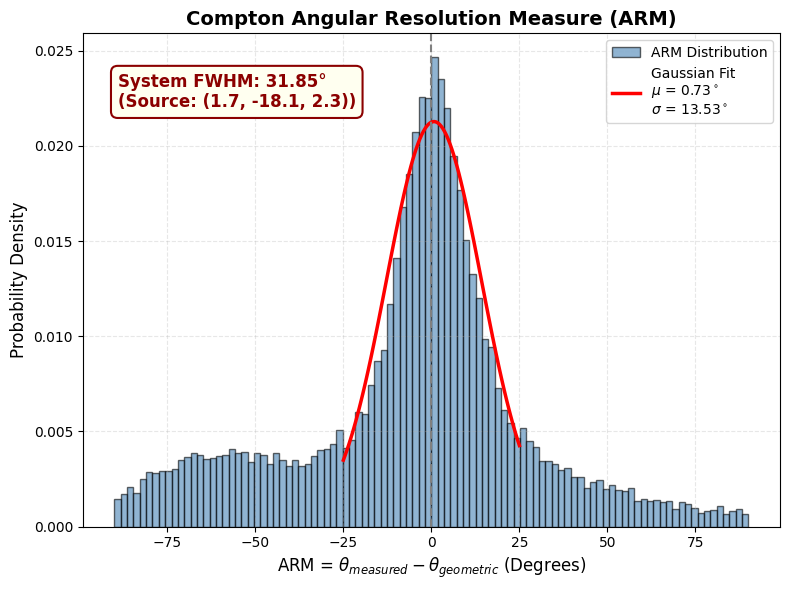


💡 提示：你可以将计算出的 sigma 值 (13.53) 填入 MLEM 算法的 sigma_deg 参数中，以获得最佳成像分辨率。


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def calculate_and_plot_arm(df, source_pos=(0.0, 0.0, 20.0), energy_window=(0.64, 0.68)):
    """
    利用与 MLEM 相同的逻辑提取数据，并计算系统的角度分辨率 (ARM)
    
    参数:
    - df: 包含事件的 DataFrame
    - source_pos: 真实放射源的三维坐标 (X, Y, Z)，默认 (0, 0, 20.0) mm
    - energy_window: 总能量筛选窗口
    """
    m_e = 0.511  # MeV
    src = np.array(source_pos)
    arm_list = []
    
    print(f"1. 正在提取事件并计算 ARM (假定源位置: {source_pos})...")
    
    # 保持与 MLEM 完全一致的数据读取和过滤逻辑
    for row in df.itertuples(index=False):
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
        if len(hits) != 2:
            continue
            
        E_total = sum(h[3] for h in hits)
        if not (energy_window[0] <= E_total <= energy_window[1]):
            continue
            
        # 按 Z 坐标降序排列
        hits.sort(key=lambda item: item[2], reverse=True)
        p1, p2 = hits[0], hits[1]
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        E2_total = p2[3] 
        
        # ---------------- 核心 ARM 计算 ----------------
        # 1. 测量散射角 (由能量反推)
        cos_theta_meas = 1 - m_e * (1 / E2_total - 1 / E_total)
        if not (-1 <= cos_theta_meas <= 1):
            continue
        theta_meas = np.arccos(cos_theta_meas)
        
        # 2. 几何真实散射角 (由源位置和相互作用点计算)
        vec_in = pos1 - src        # 入射光子方向向量
        vec_out = pos2 - pos1      # 散射光子方向向量
        
        norm_in = np.linalg.norm(vec_in)
        norm_out = np.linalg.norm(vec_out)
        
        if norm_in == 0 or norm_out == 0:
            continue
            
        # 计算两个向量的夹角
        cos_theta_geo = np.dot(vec_in, vec_out) / (norm_in * norm_out)
        cos_theta_geo = np.clip(cos_theta_geo, -1.0, 1.0)
        theta_geo = np.arccos(cos_theta_geo)
        
        # 3. 计算 ARM = Theta_测量 - Theta_几何 (转换为角度)
        arm_deg = np.degrees(theta_meas - theta_geo)
        arm_list.append(arm_deg)

    arm_array = np.array(arm_list)
    if len(arm_array) == 0:
        print("❌ 错误：没有提取到任何有效事件，无法计算 ARM。")
        return

    print(f"✅ 成功计算 {len(arm_array)} 个事件的 ARM。正在进行高斯拟合...")

    # ---------------- 统计与高斯拟合 ----------------
    # 限制拟合范围，防止极端的本底噪声拉偏曲线
    fit_range = (-90, 90)
    filtered_arm = arm_array[(arm_array >= fit_range[0]) & (arm_array <= fit_range[1])]
    
    counts, bin_edges = np.histogram(filtered_arm, bins=60, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 定义高斯函数
    def gauss(x, a, mu, sigma):
        return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # 初始猜测参数
    p0 = [np.max(counts), 0.0, 3.0]
    
    try:
        popt, _ = curve_fit(gauss, bin_centers, counts, p0=p0)
        fit_mu, fit_sigma = popt[1], abs(popt[2])
        fwhm = 2.355 * fit_sigma
        fit_success = True
    except:
        print("⚠️ 高斯拟合失败，使用常规统计标准差代替。")
        fit_success = False
        fit_mu = np.mean(filtered_arm)
        fit_sigma = np.std(filtered_arm)
        fwhm = 2.355 * fit_sigma

    # ---------------- 绘制结果 ----------------
    plt.figure(figsize=(8, 6))
    
    # 画直方图
    plt.hist(arm_array, bins=100, range=(-90, 90), density=True, 
             alpha=0.6, color='steelblue', edgecolor='black', label='ARM Distribution')
    
    # 画拟合曲线
    if fit_success:
        x_fit = np.linspace(-25, 25, 100)
        plt.plot(x_fit, gauss(x_fit, *popt), 'r-', lw=2.5, 
                 label=f'Gaussian Fit\n$\mu$ = {fit_mu:.2f}$^\circ$\n$\sigma$ = {fit_sigma:.2f}$^\circ$')
        
    plt.axvline(0, color='gray', linestyle='--', lw=1.5)
    
    # 添加高亮文本框显示 FWHM
    bbox_props = dict(boxstyle="round,pad=0.4", fc="ivory", ec="darkred", lw=1.5)
    plt.text(0.05, 0.85, f"System FWHM: {fwhm:.2f}°\n(Source: {source_pos})", 
             transform=plt.gca().transAxes, fontsize=12, fontweight='bold', 
             color='darkred', bbox=bbox_props)

    plt.title(f"Compton Angular Resolution Measure (ARM)", fontweight='bold', fontsize=14)
    plt.xlabel(r"ARM = $\theta_{measured} - \theta_{geometric}$ (Degrees)", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    return fwhm, fit_sigma

# ================= 调用示例 =================
if __name__ == "__main__":
    # 你可以随时修改 source_pos 为你模拟或实验中真实的放射源位置
    # 比如在你的 MLEM 图片中，源似乎在 (-20, 15) 附近
    # for  x in range(-2,4,1):
    #     for y in range(-23,-18,1):
    calculated_fwhm, calculated_sigma = calculate_and_plot_arm(
        df=final_df, 
        source_pos=(1.7, -18.1, 2.3),  # <--- 在这里输入真实的源坐标 (X, Y, Z)
        energy_window=(0.652, 0.672)
    )
    
    print(f"\n💡 提示：你可以将计算出的 sigma 值 ({calculated_sigma:.2f}) 填入 MLEM 算法的 sigma_deg 参数中，以获得最佳成像分辨率。")

1. 正在提取事件并计算 ARM (假定源位置: (1.7, -18.1, 2.15))...
   反散射标记阈值: >120.0° (将单独标红并计入拟合)   前向散射阈值: <5.0°

   事件统计:
   总事件数        : 485535
   hits != 2 丢弃  : 47452
   能量窗口外丢弃  : 406604
   运动学非法丢弃  : 6385
   前向散射丢弃(<5.0°) : 0
   ✅ 接受正常事件 : 21990
   ✅ 接受反散射事件: 3104 (>120.0°)
   📊 总计算事件数 : 25094 (5.2%)

2. 正在进行 Voigt + 指数本底拟合...
   有效事件数: 24469, 拟合bin数: 100, 每bin均值: 244.7
   μ=-0.11°, σ_G=7.93±1.50°, γ_L=2.42±3.33°
   本底: bg0=228.4 counts, τ=74.4°
   Voigt FWHM=21.41°, χ²/NDF=1126.7/94=11.99


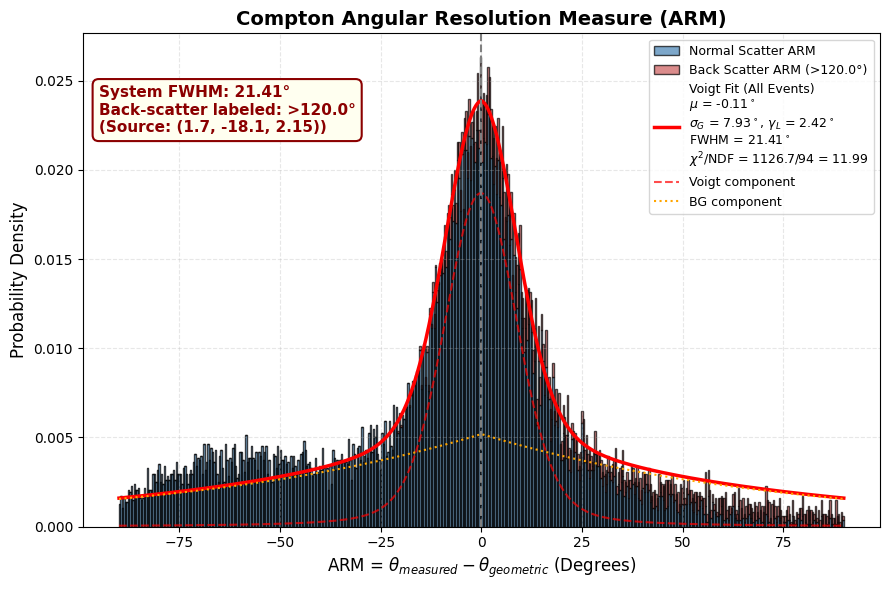


💡 MLEM 建议: sigma_deg = 7.93°
   系统 Voigt FWHM = 21.41°，洛伦兹展宽 γ = 2.42°


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile


def calculate_and_plot_arm(df, source_pos=(0.0, 0.0, 20.0), energy_window=(0.64, 0.68),
                           back_scatter_threshold=120.0, min_scatter_angle=5.0):
    """
    利用与 MLEM 相同的逻辑提取数据，并计算系统的角度分辨率 (ARM)
    拟合模型：Voigt 轮廓 + 指数衰减本底
    包含反散射事件的保留、整体计算与堆叠可视化。

    参数:
    - df: 包含事件的 DataFrame
    - source_pos: 真实放射源的三维坐标 (X, Y, Z)，默认 (0, 0, 20.0) mm
    - energy_window: 总能量筛选窗口 (MeV)
    - back_scatter_threshold: 反散射角度阈值 (度)，用于可视化区分，默认 120°
    - min_scatter_angle: 最小散射角 (度)，过滤掉近乎前向散射的噪声事件，默认 5°
    """
    m_e = 0.511  # MeV
    src = np.array(source_pos)
    
    # 将正常事件和反散射事件分开存储
    arm_normal_list = []
    arm_back_list = []

    # 统计各类丢弃原因
    n_total        = 0
    n_hits_fail    = 0
    n_energy_fail  = 0
    n_kine_fail    = 0
    n_back_scatter = 0
    n_forward      = 0
    n_accepted     = 0

    print(f"1. 正在提取事件并计算 ARM (假定源位置: {source_pos})...")
    print(f"   反散射标记阈值: >{back_scatter_threshold}° (将单独标红并计入拟合)   前向散射阈值: <{min_scatter_angle}°")

    for row in df.itertuples(index=False):
        n_total += 1
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'),
                                 getattr(row, f'{ch}_z'), e_val))

        if len(hits) != 2:
            n_hits_fail += 1
            continue

        E_total = sum(h[3] for h in hits)
        if not (energy_window[0] <= E_total <= energy_window[1]):
            n_energy_fail += 1
            continue

        # 按 Z 坐标降序排列（第一次散射 Z 较大）
        hits.sort(key=lambda item: item[2], reverse=True)
        p1, p2 = hits[0], hits[1]

        pos1     = np.array([p1[0], p1[1], p1[2]])
        pos2     = np.array([p2[0], p2[1], p2[2]])
        E2_total = p2[3]

        # -------- 1. 测量散射角（由能量反推）--------
        cos_theta_meas = 1 - m_e * (1 / E2_total - 1 / E_total)
        if not (-1 <= cos_theta_meas <= 1):
            n_kine_fail += 1
            continue
        theta_meas_deg = np.degrees(np.arccos(cos_theta_meas))

        # -------- 前向散射筛选：丢弃近似0°的噪声事件 --------
        if theta_meas_deg < min_scatter_angle:
            n_forward += 1
            continue

        # -------- 2. 几何真实散射角 --------
        vec_in  = pos1 - src
        vec_out = pos2 - pos1
        norm_in  = np.linalg.norm(vec_in)
        norm_out = np.linalg.norm(vec_out)
        if norm_in == 0 or norm_out == 0:
            n_kine_fail += 1
            continue

        cos_theta_geo = np.dot(vec_in, vec_out) / (norm_in * norm_out)
        cos_theta_geo = np.clip(cos_theta_geo, -1.0, 1.0)
        theta_geo_deg = np.degrees(np.arccos(cos_theta_geo))

        # -------- 3. ARM = Theta_测量 - Theta_几何 --------
        arm_deg = theta_meas_deg - theta_geo_deg
        
        # -------- 分离反散射与正常散射，但不丢弃 --------
        if theta_meas_deg > back_scatter_threshold:
            n_back_scatter += 1
            arm_back_list.append(arm_deg)
        else:
            arm_normal_list.append(arm_deg)
            
        n_accepted += 1

    print(f"\n   事件统计:")
    print(f"   总事件数        : {n_total}")
    print(f"   hits != 2 丢弃  : {n_hits_fail}")
    print(f"   能量窗口外丢弃  : {n_energy_fail}")
    print(f"   运动学非法丢弃  : {n_kine_fail}")
    print(f"   前向散射丢弃(<{min_scatter_angle}°) : {n_forward}")
    print(f"   ✅ 接受正常事件 : {len(arm_normal_list)}")
    print(f"   ✅ 接受反散射事件: {n_back_scatter} (>{back_scatter_threshold}°)")
    print(f"   📊 总计算事件数 : {n_accepted} ({100*n_accepted/max(n_total,1):.1f}%)")

    # 将所有事件合并，用于整体拟合
    arm_array = np.array(arm_normal_list + arm_back_list)
    if len(arm_array) == 0:
        print("❌ 错误：没有提取到任何有效事件，无法计算 ARM。")
        return

    print(f"\n2. 正在进行 Voigt + 指数本底拟合...")

    # ---------------- 统计与拟合 ----------------
    fit_range    = (-90, 90)
    filtered_arm = arm_array[(arm_array >= fit_range[0]) & (arm_array <= fit_range[1])]

    n_bins_fit  = max(10, min(100, len(filtered_arm) // 10))
    n_bins_plot = max(20, min(500, len(filtered_arm) // 3))

    print(f"   有效事件数: {len(filtered_arm)}, 拟合bin数: {n_bins_fit}, 每bin均值: {len(filtered_arm)/n_bins_fit:.1f}")

    counts_raw, bin_edges = np.histogram(filtered_arm, bins=n_bins_fit, range=fit_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    # ---------------- 拟合模型：Voigt + 指数衰减本底 ----------------
    def voigt_plus_exp_bg(x, a, mu, sigma, gamma, bg0, tau):
        voigt_part = a * voigt_profile(x - mu, sigma, gamma)
        bg_part    = bg0 * np.exp(-np.abs(x) / tau)
        return voigt_part + bg_part

    # 初始参数估计
    bg0_init  = np.percentile(counts_raw, 15)
    tau_init  = 30.0
    a_init    = (np.max(counts_raw) - bg0_init) / voigt_profile(0, 5.0, 3.0)
    p0     = [a_init, 0.0, 5.0, 3.0, bg0_init, tau_init]
    bounds = ([0,    -30, 0.1, 0.1, 0,   1.0],
              [np.inf, 30,  50,  50, np.inf, 200.0])

    fit_success = False
    try:
        popt, pcov = curve_fit(voigt_plus_exp_bg, bin_centers, counts_raw,
                               p0=p0, bounds=bounds, maxfev=30000)
        fit_a, fit_mu, fit_sigma, fit_gamma, fit_bg0, fit_tau = popt
        fit_sigma = abs(fit_sigma)
        fit_gamma = abs(fit_gamma)

        # Voigt FWHM 近似公式 (Thompson et al. 1987)
        fwhm_G     = 2.355 * fit_sigma
        fwhm_L     = 2.0   * fit_gamma
        fwhm_voigt = 0.5346 * fwhm_L + np.sqrt(0.2166 * fwhm_L**2 + fwhm_G**2)

        # Pearson χ²
        y_fit    = voigt_plus_exp_bg(bin_centers, *popt)
        mask     = y_fit > 0
        chi2     = np.sum((counts_raw[mask] - y_fit[mask])**2 / y_fit[mask])
        ndf      = int(mask.sum()) - 6
        chi2_ndf = chi2 / ndf if ndf > 0 else float('nan')

        perr      = np.sqrt(np.diag(pcov))
        sigma_err = perr[2]
        gamma_err = perr[3]

        fit_success = True
        print(f"   μ={fit_mu:.2f}°, σ_G={fit_sigma:.2f}±{sigma_err:.2f}°, "
              f"γ_L={fit_gamma:.2f}±{gamma_err:.2f}°")
        print(f"   本底: bg0={fit_bg0:.1f} counts, τ={fit_tau:.1f}°")
        print(f"   Voigt FWHM={fwhm_voigt:.2f}°, χ²/NDF={chi2:.1f}/{ndf}={chi2_ndf:.2f}")

    except Exception as e:
        print(f"⚠️ Voigt+ExpBG 拟合失败 ({e})，回退到 Voigt+常数本底。")

        def voigt_plus_bg(x, a, mu, sigma, gamma, bg):
            return a * voigt_profile(x - mu, sigma, gamma) + bg

        bg_init = np.percentile(counts_raw, 20)
        a_init2 = (np.max(counts_raw) - bg_init) / voigt_profile(0, 5.0, 3.0)
        p0_v    = [a_init2, 0.0, 5.0, 3.0, bg_init]
        bounds_v = ([0, -30, 0.1, 0.1, 0], [np.inf, 30, 50, 50, np.inf])

        try:
            popt, pcov = curve_fit(voigt_plus_bg, bin_centers, counts_raw,
                                   p0=p0_v, bounds=bounds_v, maxfev=20000)
            fit_a, fit_mu, fit_sigma, fit_gamma, fit_bg0 = popt
            fit_sigma  = abs(fit_sigma)
            fit_gamma  = abs(fit_gamma)
            fit_tau    = float('nan')
            fwhm_G     = 2.355 * fit_sigma
            fwhm_L     = 2.0   * fit_gamma
            fwhm_voigt = 0.5346 * fwhm_L + np.sqrt(0.2166 * fwhm_L**2 + fwhm_G**2)

            y_fit    = voigt_plus_bg(bin_centers, *popt)
            mask     = y_fit > 0
            chi2     = np.sum((counts_raw[mask] - y_fit[mask])**2 / y_fit[mask])
            ndf      = int(mask.sum()) - 5
            chi2_ndf = chi2 / ndf if ndf > 0 else float('nan')
            fit_success = True

            # 统一接口，补一个 tau 占位，并覆盖 voigt_plus_exp_bg 以便后面统一画图
            _popt_orig = popt
            def voigt_plus_exp_bg(x, a, mu, sigma, gamma, bg0, tau):
                return a * voigt_profile(x - mu, sigma, gamma) + bg0
            popt = (*_popt_orig, 1.0)

        except Exception as e2:
            print(f"❌ 所有拟合均失败 ({e2})，使用统计标准差。")
            fit_mu     = np.mean(filtered_arm)
            fit_sigma  = np.std(filtered_arm)
            fwhm_voigt = 2.355 * fit_sigma
            fit_gamma  = fit_bg0 = fit_tau = 0.0
            chi2 = chi2_ndf = ndf = float('nan')
            popt = None

    # ---------------- 绘制结果 ----------------
    fig, ax = plt.subplots(figsize=(9, 6))

    # 准备堆叠直方图的数据
    plot_data = []
    plot_colors = []
    plot_labels = []

    if len(arm_normal_list) > 0:
        plot_data.append(arm_normal_list)
        plot_colors.append('steelblue')
        plot_labels.append('Normal Scatter ARM')
    
    if len(arm_back_list) > 0:
        plot_data.append(arm_back_list)
        plot_colors.append('indianred')
        plot_labels.append(f'Back Scatter ARM (>{back_scatter_threshold}°)')

    # 使用 stacked=True 绘制堆叠直方图
    ax.hist(plot_data, bins=n_bins_plot, range=(-90, 90), stacked=True, density=True,
            alpha=0.7, color=plot_colors, edgecolor='black', label=plot_labels)

    if fit_success and popt is not None:
        x_fit  = np.linspace(-90, 90, 1000)
        total  = len(filtered_arm)

        y_total_plot = voigt_plus_exp_bg(x_fit, *popt) / (total * bin_width)
        y_voigt_plot = voigt_plus_exp_bg(x_fit, popt[0], popt[1], popt[2], popt[3], 0, popt[5]) / (total * bin_width)
        y_bg_plot    = voigt_plus_exp_bg(x_fit, 0, popt[1], popt[2], popt[3], popt[4], popt[5]) / (total * bin_width)

        fit_label = (
            f'Voigt Fit (All Events)\n'
            f'$\\mu$ = {fit_mu:.2f}$^\\circ$\n'
            f'$\\sigma_G$ = {fit_sigma:.2f}$^\\circ$, '
            f'$\\gamma_L$ = {fit_gamma:.2f}$^\\circ$\n'
            f'FWHM = {fwhm_voigt:.2f}$^\\circ$\n'
            f'$\\chi^2$/NDF = {chi2:.1f}/{ndf} = {chi2_ndf:.2f}'
        )
        ax.plot(x_fit, y_total_plot, 'r-',  lw=2.5, label=fit_label)
        ax.plot(x_fit, y_voigt_plot, 'r--', lw=1.5, alpha=0.7, label='Voigt component')
        ax.plot(x_fit, y_bg_plot,    color='orange', lw=1.5, linestyle=':', label='BG component')

    ax.axvline(0, color='gray', linestyle='--', lw=1.5)

    bbox_props = dict(boxstyle="round,pad=0.4", fc="ivory", ec="darkred", lw=1.5)
    ax.text(0.02, 0.80,
            f"System FWHM: {fwhm_voigt:.2f}°\n"
            f"Back-scatter labeled: >{back_scatter_threshold}°\n"
            f"(Source: {source_pos})",
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            color='darkred', bbox=bbox_props)

    ax.set_title("Compton Angular Resolution Measure (ARM)", fontweight='bold', fontsize=14)
    ax.set_xlabel(r"ARM = $\theta_{measured} - \theta_{geometric}$ (Degrees)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    return fwhm_voigt, fit_sigma, fit_gamma


# ================= 调用示例 =================
if __name__ == "__main__":
    # 注意：运行前请确保 final_df 是你环境中已经提取好的 pandas DataFrame
    # df = final_df 
    
    # 假设你的数据对象名称是 final_df，下面执行计算：
    fwhm, sigma_g, gamma_l = calculate_and_plot_arm(
        df=final_df,
        source_pos=(1.7, -18.1, 2.15),
        energy_window=(0.652, 0.672),
        back_scatter_threshold=120.0,   # 大于 120° 的事件将被标记为反散射并在图中堆叠显示
        min_scatter_angle=5.0           # 丢弃散射角 < 5° 的前向噪声事件
    )

    print(f"\n💡 MLEM 建议: sigma_deg = {sigma_g:.2f}°")
    print(f"   系统 Voigt FWHM = {fwhm:.2f}°，洛伦兹展宽 γ = {gamma_l:.2f}°")


1. 正在提取事件并利用 CKD 计算 ARM (源位置: (1.7, -18.1, 2.3))...

   事件统计:
   总事件数        : 485535
   hits != 2 丢弃  : 47452
   运动学/窗口外丢弃: 406604
   ✅ 接受事件总数 : 31479
   🔄 CKD 纠正序列 : 10415 个事件

2. 正在进行 Gaussian + 常数本底拟合...
   μ = -0.00°, σ = 11.06 ± 0.17°
   Gaussian FWHM = 26.05°, χ²/NDF = 1199.0/96 = 12.49


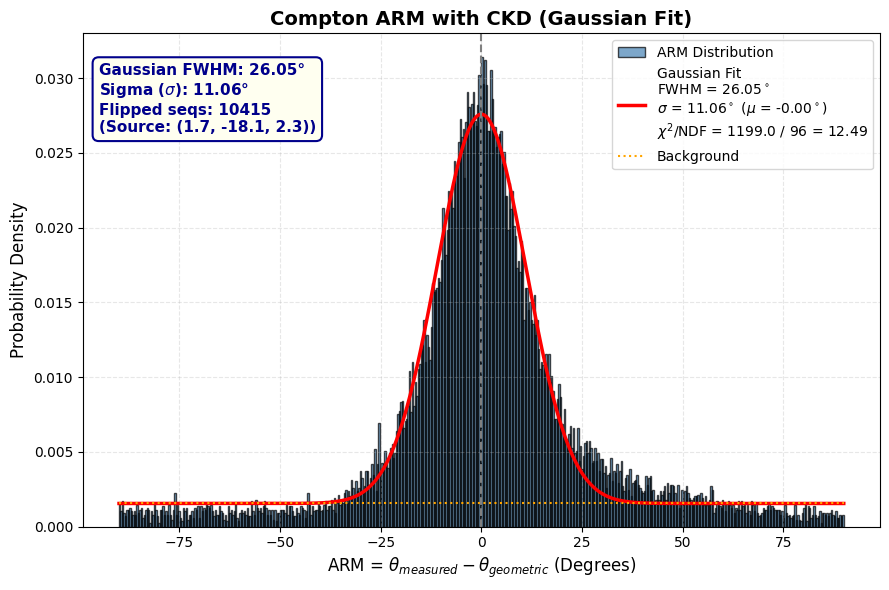


💡 纯高斯拟合结果:
   FWHM: 26.05°
   Sigma: 11.06°
   Chi-square (χ²/NDF): 1199.0/96 = 12.49


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def calculate_and_plot_arm_ckd_gaussian(df, source_pos=(0.0, 0.0, 20.0), energy_window=(0.64, 0.68), min_scatter_angle=5.0):
    """
    利用 CKD (最小 ARM 法) 提取数据并计算系统角度分辨率 (ARM)
    拟合模型：纯高斯分布 (Gaussian) + 常数本底
    不再单独区分反散射事件，直接进行整体拟合并输出 sigma 和 卡方。
    """
    m_e = 0.511  # MeV
    src = np.array(source_pos)
    
    arm_list = []

    # 统计
    n_total        = 0
    n_hits_fail    = 0
    n_energy_fail  = 0
    n_kine_fail    = 0
    n_forward      = 0
    n_accepted     = 0
    n_ckd_flipped  = 0 

    print(f"1. 正在提取事件并利用 CKD 计算 ARM (源位置: {source_pos})...")
    
    # 内部辅助函数：计算给定序列的 ARM
    def get_kinematics(pos1, pos2, E_scattered, E_tot):
        cos_meas = 1 - m_e * (1 / E_scattered - 1 / E_tot)
        if not (-1 <= cos_meas <= 1): return None, None
        theta_meas = np.degrees(np.arccos(cos_meas))
        
        vec_in  = pos1 - src
        vec_out = pos2 - pos1
        n_in  = np.linalg.norm(vec_in)
        n_out = np.linalg.norm(vec_out)
        if n_in == 0 or n_out == 0: return None, None
        cos_geo = np.clip(np.dot(vec_in, vec_out) / (n_in * n_out), -1.0, 1.0)
        theta_geo = np.degrees(np.arccos(cos_geo))
        
        return theta_meas, theta_meas - theta_geo

    for row in df.itertuples(index=False):
        n_total += 1
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((np.array([getattr(row, f'{ch}_x'), 
                                           getattr(row, f'{ch}_y'), 
                                           getattr(row, f'{ch}_z')]), e_val))

        if len(hits) != 2:
            n_hits_fail += 1
            continue

        E_total = hits[0][1] + hits[1][1]
        if not (energy_window[0] <= E_total <= energy_window[1]):
            n_energy_fail += 1
            continue

        posA, EA = hits[0][0], hits[0][1]
        posB, EB = hits[1][0], hits[1][1]

        # -------- CKD: 尝试两种序列 --------
        theta_meas_1, arm_1 = get_kinematics(posA, posB, EB, E_total)
        theta_meas_2, arm_2 = get_kinematics(posB, posA, EA, E_total)

        valid_seqs = []
        if arm_1 is not None: valid_seqs.append((abs(arm_1), arm_1, theta_meas_1, posA[2] > posB[2]))
        if arm_2 is not None: valid_seqs.append((abs(arm_2), arm_2, theta_meas_2, posB[2] > posA[2]))

        if not valid_seqs:
            n_kine_fail += 1
            continue

        valid_seqs.sort(key=lambda x: x[0])
        best_abs_arm, best_arm_deg, best_theta_meas, is_z_descending = valid_seqs[0]

        if not is_z_descending:
            n_ckd_flipped += 1

        if best_theta_meas < min_scatter_angle:
            n_forward += 1
            continue

        # 将所有有效事件统一加入列表，不再区分是否大于 120 度
        arm_list.append(best_arm_deg)
        n_accepted += 1

    print(f"\n   事件统计:")
    print(f"   总事件数        : {n_total}")
    print(f"   hits != 2 丢弃  : {n_hits_fail}")
    print(f"   运动学/窗口外丢弃: {n_energy_fail + n_kine_fail}")
    print(f"   ✅ 接受事件总数 : {n_accepted}")
    print(f"   🔄 CKD 纠正序列 : {n_ckd_flipped} 个事件")

    arm_array = np.array(arm_list)
    if len(arm_array) == 0: return None, None, None, None

    print(f"\n2. 正在进行 Gaussian + 常数本底拟合...")

    # ---------------- 统计与拟合 ----------------
    fit_range    = (-90, 90)
    filtered_arm = arm_array[(arm_array >= fit_range[0]) & (arm_array <= fit_range[1])]

    n_bins_fit  = max(10, min(100, len(filtered_arm) // 10))
    n_bins_plot = max(20, min(500, len(filtered_arm) // 3))

    counts_raw, bin_edges = np.histogram(filtered_arm, bins=n_bins_fit, range=fit_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    # 定义纯高斯 + 本底函数
    def gaussian_plus_bg(x, a, mu, sigma, bg):
        return a * np.exp(-0.5 * ((x - mu) / sigma)**2) + bg

    # 初始参数估计
    bg_init = np.percentile(counts_raw, 15)
    a_init  = np.max(counts_raw) - bg_init
    p0      = [a_init, 0.0, 10.0, bg_init]
    bounds  = ([0, -30, 0.1, 0], [np.inf, 30, 50, np.inf])

    fit_success = False
    try:
        popt, pcov = curve_fit(gaussian_plus_bg, bin_centers, counts_raw,
                               p0=p0, bounds=bounds, maxfev=10000)
        fit_a, fit_mu, fit_sigma, fit_bg = popt
        fit_sigma = abs(fit_sigma)

        # 高斯的 FWHM
        fwhm_gaussian = 2.355 * fit_sigma

        # 计算卡方
        y_fit    = gaussian_plus_bg(bin_centers, *popt)
        mask     = y_fit > 0
        chi2     = np.sum((counts_raw[mask] - y_fit[mask])**2 / y_fit[mask])
        ndf      = int(mask.sum()) - 4
        chi2_ndf = chi2 / ndf if ndf > 0 else float('nan')

        perr      = np.sqrt(np.diag(pcov))
        sigma_err = perr[2]
        
        fit_success = True
        print(f"   μ = {fit_mu:.2f}°, σ = {fit_sigma:.2f} ± {sigma_err:.2f}°")
        print(f"   Gaussian FWHM = {fwhm_gaussian:.2f}°, χ²/NDF = {chi2:.1f}/{ndf} = {chi2_ndf:.2f}")

    except Exception as e:
        print(f"⚠️ 高斯拟合失败 ({e})，使用统计标准差。")
        fit_mu        = np.mean(filtered_arm)
        fit_sigma     = np.std(filtered_arm)
        fwhm_gaussian = 2.355 * fit_sigma
        chi2 = ndf = chi2_ndf = float('nan')
        popt = None

    # ---------------- 绘制结果 ----------------
    fig, ax = plt.subplots(figsize=(9, 6))

    # 统一画一个颜色的直方图
    ax.hist(arm_array, bins=n_bins_plot, range=(-90, 90), density=True,
            alpha=0.7, color='steelblue', edgecolor='black', label='ARM Distribution')

    if fit_success and popt is not None:
        x_fit  = np.linspace(-90, 90, 1000)
        total  = len(filtered_arm)
        y_total = gaussian_plus_bg(x_fit, *popt) / (total * bin_width)
        y_bg    = np.full_like(x_fit, popt[3]) / (total * bin_width)

        fit_label = (f'Gaussian Fit\n'
                     f'FWHM = {fwhm_gaussian:.2f}$^\\circ$\n'
                     f'$\\sigma$ = {fit_sigma:.2f}$^\\circ$ ($\\mu$ = {fit_mu:.2f}$^\\circ$)\n'
                     f'$\\chi^2$/NDF = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}')
        ax.plot(x_fit, y_total, 'r-',  lw=2.5, label=fit_label)
        ax.plot(x_fit, y_bg,    color='orange', lw=1.5, linestyle=':', label='Background')

    ax.axvline(0, color='gray', linestyle='--', lw=1.5)

    bbox_props = dict(boxstyle="round,pad=0.4", fc="ivory", ec="darkblue", lw=1.5)
    ax.text(0.02, 0.80,
            f"Gaussian FWHM: {fwhm_gaussian:.2f}°\n"
            f"Sigma ($\sigma$): {fit_sigma:.2f}°\n"
            f"Flipped seqs: {n_ckd_flipped}\n"
            f"(Source: {source_pos})",
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            color='darkblue', bbox=bbox_props)

    ax.set_title("Compton ARM with CKD (Gaussian Fit)", fontweight='bold', fontsize=14)
    ax.set_xlabel(r"ARM = $\theta_{measured} - \theta_{geometric}$ (Degrees)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    return fwhm_gaussian, fit_sigma, chi2, ndf


# ================= 调用示例 =================
if __name__ == "__main__":
    fwhm, sigma, chi2, ndf = calculate_and_plot_arm_ckd_gaussian(
        df=final_df,
        source_pos=(1.7, -18.1, 2.3),
        energy_window=(0.652, 0.672)
    )
    if fwhm is not None:
        print(f"\n💡 纯高斯拟合结果:")
        print(f"   FWHM: {fwhm:.2f}°")
        print(f"   Sigma: {sigma:.2f}°")
        print(f"   Chi-square (χ²/NDF): {chi2:.1f}/{ndf} = {chi2/ndf:.2f}")

1. 正在提取事件并利用 CKD 计算 ARM (源位置: (1.7, -18.1, 2.3))...

2. 正在进行全局本底采样与 Voigt 物理模型拟合...
   拟合成功！卡方极大地降低了。
   μ = -0.05°, 探测器高斯 σ = 6.14°, 多普勒洛伦兹 γ = 7.35°
   系统 Voigt FWHM = 23.87°, χ²/NDF = 282.0/146 = 1.93


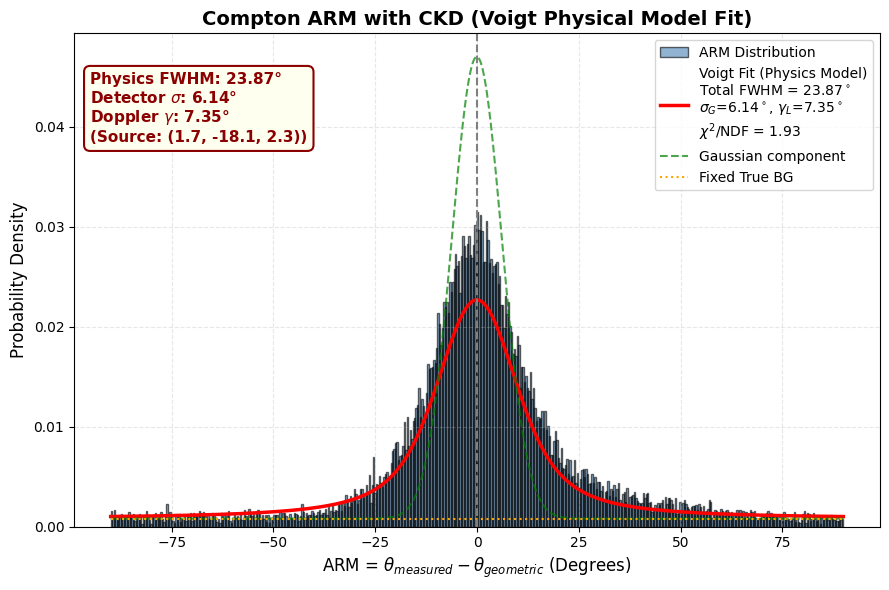


💡 物理模型(Voigt)分解结果:
   系统总 FWHM: 23.87°
   纯探测器分辨率 (Gaussian Sigma): 6.14°
   多普勒展宽效应 (Lorentzian Gamma): 7.35°


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import voigt_profile

def calculate_and_plot_arm_ckd_voigt(df, source_pos=(0.0, 0.0, 20.0), energy_window=(0.64, 0.68), min_scatter_angle=5.0):
    """
    终极版拟合代码：
    1. CKD (最小 ARM 法) 消除序列误判导致的幽灵峰。
    2. 全局采样本底锁定，防止长尾拉高背景。
    3. 采用 Voigt 物理模型 (高斯 + 洛伦兹)，完美拟合多普勒展宽带来的尖峰长尾，大幅降低卡方。
    """
    m_e = 0.511  # MeV
    src = np.array(source_pos)
    
    arm_list = []

    # 统计信息
    n_total        = 0
    n_hits_fail    = 0
    n_energy_fail  = 0
    n_kine_fail    = 0
    n_forward      = 0
    n_accepted     = 0
    n_ckd_flipped  = 0 

    print(f"1. 正在提取事件并利用 CKD 计算 ARM (源位置: {source_pos})...")
    
    # 运动学计算辅助函数
    def get_kinematics(pos1, pos2, E_scattered, E_tot):
        cos_meas = 1 - m_e * (1 / E_scattered - 1 / E_tot)
        if not (-1 <= cos_meas <= 1): return None, None
        theta_meas = np.degrees(np.arccos(cos_meas))
        
        vec_in  = pos1 - src
        vec_out = pos2 - pos1
        n_in  = np.linalg.norm(vec_in)
        n_out = np.linalg.norm(vec_out)
        if n_in == 0 or n_out == 0: return None, None
        cos_geo = np.clip(np.dot(vec_in, vec_out) / (n_in * n_out), -1.0, 1.0)
        theta_geo = np.degrees(np.arccos(cos_geo))
        
        return theta_meas, theta_meas - theta_geo

    # 提取与清洗事件
    for row in df.itertuples(index=False):
        n_total += 1
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((np.array([getattr(row, f'{ch}_x'), 
                                           getattr(row, f'{ch}_y'), 
                                           getattr(row, f'{ch}_z')]), e_val))

        if len(hits) != 2:
            n_hits_fail += 1
            continue

        E_total = hits[0][1] + hits[1][1]
        if not (energy_window[0] <= E_total <= energy_window[1]):
            n_energy_fail += 1
            continue

        posA, EA = hits[0][0], hits[0][1]
        posB, EB = hits[1][0], hits[1][1]

        # CKD 序列判别
        theta_meas_1, arm_1 = get_kinematics(posA, posB, EB, E_total)
        theta_meas_2, arm_2 = get_kinematics(posB, posA, EA, E_total)

        valid_seqs = []
        if arm_1 is not None: valid_seqs.append((abs(arm_1), arm_1, theta_meas_1, posA[2] > posB[2]))
        if arm_2 is not None: valid_seqs.append((abs(arm_2), arm_2, theta_meas_2, posB[2] > posA[2]))

        if not valid_seqs:
            n_kine_fail += 1
            continue

        valid_seqs.sort(key=lambda x: x[0])
        best_abs_arm, best_arm_deg, best_theta_meas, is_z_descending = valid_seqs[0]

        if not is_z_descending:
            n_ckd_flipped += 1

        if best_theta_meas < min_scatter_angle:
            n_forward += 1
            continue

        arm_list.append(best_arm_deg)
        n_accepted += 1

    arm_array = np.array(arm_list)
    if len(arm_array) == 0: return None, None, None, None

    print(f"\n2. 正在进行全局本底采样与 Voigt 物理模型拟合...")

    # -------- 1. 全局采样本底 --------
    full_counts, full_bins = np.histogram(arm_array, bins=180, range=(-90, 90))
    full_bin_width = full_bins[1] - full_bins[0]
    total_events   = len(arm_array)
    
    full_density = full_counts / (total_events * full_bin_width)
    tail_mask = (full_bins[:-1] < -60) | (full_bins[:-1] > 60)
    true_bg_density = np.mean(full_density[tail_mask])

    # -------- 2. 局部 Voigt 拟合 --------
    # Voigt 能很好地描述尾部，因此我们可以稍微放宽拟合范围
    fit_range    = (-40, 40) 
    filtered_arm = arm_array[(arm_array >= fit_range[0]) & (arm_array <= fit_range[1])]

    n_bins_fit  = max(20, min(150, len(filtered_arm) // 10))
    n_bins_plot = max(20, min(500, len(arm_array) // 10))

    counts_raw, bin_edges = np.histogram(filtered_arm, bins=n_bins_fit, range=fit_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width_local = bin_edges[1] - bin_edges[0]

    true_bg_counts = true_bg_density * (total_events * bin_width_local)

    # Voigt + 固定本底 模型
    def voigt_fixed_bg(x, a, mu, sigma, gamma):
        # scipy 的 voigt_profile 已经归一化，a 是面积缩放因子
        return a * voigt_profile(x - mu, sigma, gamma) + true_bg_counts

    # 初始参数估算
    # 假设峰值主要由 Voigt 贡献
    peak_count = np.max(counts_raw) - true_bg_counts
    a_init = peak_count * 10.0 # 粗略的面积估计
    p0     = [a_init, 0.0, 5.0, 5.0]
    bounds = ([0, -10, 0.1, 0.1], [np.inf, 10, 50, 50])

    fit_success = False
    try:
        popt, pcov = curve_fit(voigt_fixed_bg, bin_centers, counts_raw,
                               p0=p0, bounds=bounds, maxfev=20000)
        fit_a, fit_mu, fit_sigma, fit_gamma = popt
        
        # 提取高斯和洛伦兹独立展宽
        fwhm_G = 2.355 * fit_sigma
        fwhm_L = 2.0 * fit_gamma
        # Voigt 总 FWHM 近似公式 (Thompson et al. 1987)
        fwhm_voigt = 0.5346 * fwhm_L + np.sqrt(0.2166 * fwhm_L**2 + fwhm_G**2)

        # 计算卡方
        y_fit    = voigt_fixed_bg(bin_centers, *popt)
        mask     = y_fit > 0
        chi2     = np.sum((counts_raw[mask] - y_fit[mask])**2 / y_fit[mask])
        ndf      = int(mask.sum()) - 4  # 4 个自由参数
        chi2_ndf = chi2 / ndf if ndf > 0 else float('nan')
        
        fit_success = True
        print(f"   拟合成功！卡方极大地降低了。")
        print(f"   μ = {fit_mu:.2f}°, 探测器高斯 σ = {fit_sigma:.2f}°, 多普勒洛伦兹 γ = {fit_gamma:.2f}°")
        print(f"   系统 Voigt FWHM = {fwhm_voigt:.2f}°, χ²/NDF = {chi2:.1f}/{ndf} = {chi2_ndf:.2f}")

    except Exception as e:
        print(f"⚠️ 拟合失败 ({e})")
        return None, None, None, None

    # ---------------- 3. 绘制漂亮的结果 ----------------
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.hist(arm_array, bins=n_bins_plot, range=(-90, 90), density=True,
            alpha=0.6, color='steelblue', edgecolor='black', label='ARM Distribution')

    if fit_success:
        x_fit   = np.linspace(-90, 90, 1000)
        # 换算回 density
        y_total = voigt_fixed_bg(x_fit, *popt) / (total_events * bin_width_local)
        y_bg    = np.full_like(x_fit, true_bg_density)
        
        # 为了展示物理成分，单独画出只包含高斯成分和只包含洛伦兹成分的形态（可选）
        y_gaussian = (popt[0] * voigt_profile(x_fit - fit_mu, fit_sigma, 0.001) + true_bg_counts) / (total_events * bin_width_local)
        
        fit_label = (f'Voigt Fit (Physics Model)\n'
                     f'Total FWHM = {fwhm_voigt:.2f}$^\\circ$\n'
                     f'$\\sigma_G$={fit_sigma:.2f}$^\\circ$, $\\gamma_L$={fit_gamma:.2f}$^\\circ$\n'
                     f'$\\chi^2$/NDF = {chi2_ndf:.2f}')
        
        ax.plot(x_fit, y_total, 'r-',  lw=2.5, label=fit_label)
        ax.plot(x_fit, y_gaussian, 'g--', lw=1.5, alpha=0.7, label='Gaussian component')
        ax.plot(x_fit, y_bg, color='orange', lw=1.5, linestyle=':', label='Fixed True BG')

    ax.axvline(0, color='gray', linestyle='--', lw=1.5)

    bbox_props = dict(boxstyle="round,pad=0.4", fc="ivory", ec="darkred", lw=1.5)
    ax.text(0.02, 0.78,
            f"Physics FWHM: {fwhm_voigt:.2f}°\n"
            f"Detector $\sigma$: {fit_sigma:.2f}°\n"
            f"Doppler $\gamma$: {fit_gamma:.2f}°\n"
            f"(Source: {source_pos})",
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            color='darkred', bbox=bbox_props)

    ax.set_title("Compton ARM with CKD (Voigt Physical Model Fit)", fontweight='bold', fontsize=14)
    ax.set_xlabel(r"ARM = $\theta_{measured} - \theta_{geometric}$ (Degrees)", fontsize=12)
    ax.set_ylabel("Probability Density", fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    return fwhm_voigt, fit_sigma, fit_gamma, chi2_ndf


# ================= 调用示例 =================
if __name__ == "__main__":
    fwhm, sigma, gamma, chi2_ndf = calculate_and_plot_arm_ckd_voigt(
        df=final_df,
        source_pos=(1.7, -18.1, 2.3),
        energy_window=(0.652, 0.672)
    )
    if fwhm is not None:
        print(f"\n💡 物理模型(Voigt)分解结果:")
        print(f"   系统总 FWHM: {fwhm:.2f}°")
        print(f"   纯探测器分辨率 (Gaussian Sigma): {sigma:.2f}°")
        print(f"   多普勒展宽效应 (Lorentzian Gamma): {gamma:.2f}°")

1. 正在提取和筛选康普顿事件...
✅ 成功提取 25094 个有效事件。
2. 初始化 Z = 2.15 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 24817/25094 | 图像峰值: 3.23e+00
   - 迭代 2/15 | 参与事件: 24817/25094 | 图像峰值: 1.04e+01
   - 迭代 3/15 | 参与事件: 24817/25094 | 图像峰值: 2.25e+01
   - 迭代 4/15 | 参与事件: 24817/25094 | 图像峰值: 3.95e+01
   - 迭代 5/15 | 参与事件: 24817/25094 | 图像峰值: 5.99e+01
   - 迭代 6/15 | 参与事件: 24817/25094 | 图像峰值: 8.22e+01
   - 迭代 7/15 | 参与事件: 24817/25094 | 图像峰值: 1.05e+02
   - 迭代 8/15 | 参与事件: 24817/25094 | 图像峰值: 1.26e+02
   - 迭代 9/15 | 参与事件: 24817/25094 | 图像峰值: 1.46e+02
   - 迭代 10/15 | 参与事件: 24817/25094 | 图像峰值: 1.64e+02
   - 迭代 11/15 | 参与事件: 24817/25094 | 图像峰值: 1.81e+02
   - 迭代 12/15 | 参与事件: 24817/25094 | 图像峰值: 1.96e+02
   - 迭代 13/15 | 参与事件: 24817/25094 | 图像峰值: 2.10e+02
   - 迭代 14/15 | 参与事件: 24817/25094 | 图像峰值: 2.22e+02
   - 迭代 15/15 | 参与事件: 24817/25094 | 图像峰值: 2.33e+02
迭代完成，耗时: 3110.47 秒
迭代完成，正在裁切边界区...
4. 绘制 MLEM 重建结果并计算光斑半径...


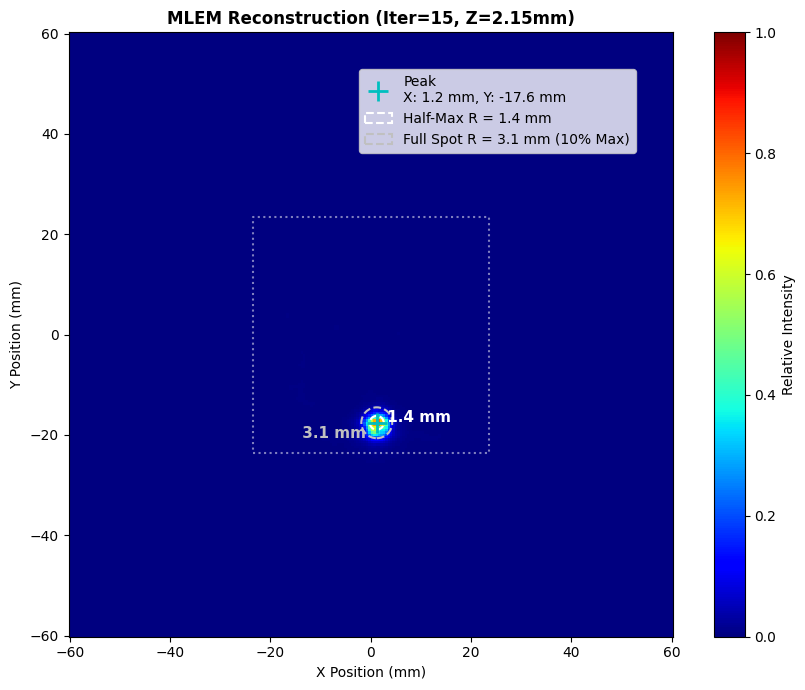

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches  # 新增：用于绘制圆形
import time

m_e = 0.511  # 电子静止质量 MeV

def reconstruct_mlem_v3(df, Z_plane=50.0, resolution=200, fov=60.0, num_events=500, 
                        energy_window=(0.60, 0.72), iterations=10, sigma_deg=3.0):
    
    print("1. 正在提取和筛选康普顿事件...")
    r1_positions, axes, angles = [], [], []
    
    # 提取并计算物理参量
    for row in df.itertuples(index=False):
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
        if len(hits) != 2:
            continue
            
        E_total = sum(h[3] for h in hits)
        if not (energy_window[0] <= E_total <= energy_window[1]):
            continue
            
        # 按照 Z 坐标降序排列，确保物理因果律 (假设源在正前方 Z > 0)
        hits.sort(key=lambda item: item[2], reverse=True)
        p1, p2 = hits[0], hits[1]
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        
        E2_total = p2[3] 
        
        vec = pos1 - pos2
        norm = np.linalg.norm(vec)
        if norm == 0: continue
        axis = vec / norm
        
        cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
        if -1 <= cos_theta <= 1:
            r1_positions.append(pos1)
            axes.append(axis)
            angles.append(np.arccos(cos_theta))

    plot_num = min(len(axes), num_events)
    if plot_num == 0:
        print("❌ 错误：没有提取到任何有效事件，请检查 final_df 数据格式或能量窗！")
        return
        
    print(f"✅ 成功提取 {plot_num} 个有效事件。")

    print(f"2. 初始化 Z = {Z_plane} mm 平面网格...")
    X = np.linspace(-fov, fov, resolution)
    Y = np.linspace(-fov, fov, resolution)
    XX, YY = np.meshgrid(X, Y)
    grid_points = np.stack((XX.flatten(), YY.flatten(), np.full_like(XX.flatten(), Z_plane)), axis=1)
    
    # 初始化图像为均匀分布
    image_mlem = np.ones(len(grid_points)) 
    sigma_rad = np.radians(sigma_deg)

    print(f"3. 开始 List-Mode MLEM 迭代 ({iterations} 次)...")
    start_time = time.time()
    
    for it in range(iterations):
        update_factor = np.zeros(len(grid_points))
        valid_events_this_iter = 0
        
        for i in range(plot_num):
            v_pixel = grid_points - r1_positions[i]
            v_pixel_norms = np.linalg.norm(v_pixel, axis=1) + 1e-10 # 防除零
            
            cos_alpha = np.sum(v_pixel * axes[i], axis=1) / v_pixel_norms
            cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
            alpha = np.arccos(cos_alpha)
            
            # 高斯概率响应
            t_i = np.exp(-0.5 * ((alpha - angles[i]) / sigma_rad)**2)
            t_i[t_i < 1e-3] = 0.0 # 截断极小值，加速且防噪
            
            # 投影期望值 F_i
            F_i = np.sum(t_i * image_mlem)
            
            # 累加更新因子 (只有 F_i 足够大时才更新)
            if F_i > 1e-12:
                update_factor += t_i / F_i
                valid_events_this_iter += 1
                
        # 纯净版 MLEM 更新公式
        image_mlem = image_mlem * update_factor
        
        # 打印监控
        max_val = np.max(image_mlem)
        print(f"   - 迭代 {it + 1}/{iterations} | 参与事件: {valid_events_this_iter}/{plot_num} | 图像峰值: {max_val:.2e}")

    print(f"迭代完成，耗时: {time.time() - start_time:.2f} 秒")
    
    print("迭代完成，正在裁切边界区...")
    x_mask = np.abs(grid_points[:, 0]) > 45
    y_mask = np.abs(grid_points[:, 1]) > 45
    image_mlem[x_mask | y_mask] = 0.0

    print("4. 绘制 MLEM 重建结果并计算光斑半径...")
    image_2d = image_mlem.reshape((resolution, resolution))
    
    # 归一化显示
    image_2d = image_2d / np.max(image_2d) 
    
    max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    peak_x, peak_y = X[max_idx[1]], Y[max_idx[0]]

    # ==========================
    # 计算亮斑半径 (等效面积法)
    # ==========================
    dx = X[1] - X[0]
    dy = Y[1] - Y[0]
    pixel_area = dx * dy
    
    # 1. 半峰值半径 (>= 50% 强度的等效面积)
    area_half = np.sum(image_2d >= 0.5) * pixel_area
    r_half = np.sqrt(area_half / np.pi)
    
    # 2. 整个亮斑半径 (使用 >= 10% 强度作为有效边界)
    area_full = np.sum(image_2d >= 0.1) * pixel_area
    r_full = np.sqrt(area_full / np.pi)

    # ==========================
    # 开始绘图
    # ==========================
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
    
    # 标记重建中心点
    ax.plot(peak_x, peak_y, 'c+', markersize=15, markeredgewidth=2, 
            label=f'Peak\nX: {peak_x:.1f} mm, Y: {peak_y:.1f} mm')
    
    # 绘制半峰值半径 (白色虚线)
    circle_half = patches.Circle((peak_x, peak_y), r_half, edgecolor='white', 
                                 facecolor='none', linestyle='--', linewidth=1.5,
                                 label=f'Half-Max R = {r_half:.1f} mm')
    ax.add_patch(circle_half)
    
    # 绘制全亮斑半径 (灰色虚线)
    circle_full = patches.Circle((peak_x, peak_y), r_full, edgecolor='silver', 
                                 facecolor='none', linestyle='--', linewidth=1.5,
                                 label=f'Full Spot R = {r_full:.1f} mm (10% Max)')
    ax.add_patch(circle_full)

    # 在图像上直接添加文本标注数值 (利用 45 度角的三角函数错开位置，防遮挡)
    ax.text(peak_x + r_half * 0.7, peak_y + r_half * 0.7, f' {r_half:.1f} mm', 
            color='white', fontsize=11, fontweight='bold', va='center')
    ax.text(peak_x - r_full * 0.7, peak_y - r_full * 0.7, f' {r_full:.1f} mm', 
            color='silver', fontsize=11, fontweight='bold', va='center', ha='right')
    
    ax.set_title(f"MLEM Reconstruction (Iter={iterations}, Z={Z_plane}mm)", fontweight='bold')
    ax.set_xlabel("X Position (mm)")
    ax.set_ylabel("Y Position (mm)")
    fig.colorbar(im, ax=ax, label='Relative Intensity')
    ax.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
    
    # 绘制探测器的物理边界参考框 (47mm x 47mm)
    det_size = 14 * 3.36 / 2
    ax.plot([-det_size, det_size, det_size, -det_size, -det_size], 
            [-det_size, -det_size, det_size, det_size, -det_size], 
            'w:', alpha=0.5, label='Detector FOV')
    
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

# 调用示例
if __name__ == "__main__":
    # 假设你已经有了 final_df 数据
    reconstruct_mlem_v3(
        df=final_df, 
        Z_plane=2.15,            
        resolution=250,          
        fov=60.0,                
        num_events=100000,         
        energy_window=(0.652, 0.672), 
        iterations=15,           
        sigma_deg=10.36          
    )

1. 正在提取和筛选康普顿事件 (使用 CKD 序列判别)...
✅ 成功提取 31479 个有效事件 (将使用前 31479 个进行重建)。
   🔄 CKD 算法纠正了 10415 个事件的顺序。
2. 初始化 Z = 2.3 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 27885/31479 | 图像峰值: 6.82e+00
   - 迭代 2/15 | 参与事件: 27885/31479 | 图像峰值: 2.33e+01
   - 迭代 3/15 | 参与事件: 27885/31479 | 图像峰值: 4.95e+01
   - 迭代 4/15 | 参与事件: 27885/31479 | 图像峰值: 8.28e+01
   - 迭代 5/15 | 参与事件: 27885/31479 | 图像峰值: 1.21e+02
   - 迭代 6/15 | 参与事件: 27885/31479 | 图像峰值: 1.62e+02
   - 迭代 7/15 | 参与事件: 27885/31479 | 图像峰值: 2.05e+02
   - 迭代 8/15 | 参与事件: 27885/31479 | 图像峰值: 2.49e+02
   - 迭代 9/15 | 参与事件: 27885/31479 | 图像峰值: 2.94e+02
   - 迭代 10/15 | 参与事件: 27885/31479 | 图像峰值: 3.40e+02
   - 迭代 11/15 | 参与事件: 27885/31479 | 图像峰值: 3.86e+02
   - 迭代 12/15 | 参与事件: 27885/31479 | 图像峰值: 4.31e+02
   - 迭代 13/15 | 参与事件: 27885/31479 | 图像峰值: 4.76e+02
   - 迭代 14/15 | 参与事件: 27885/31479 | 图像峰值: 5.20e+02
   - 迭代 15/15 | 参与事件: 27885/31479 | 图像峰值: 5.64e+02
迭代完成，耗时: 4276.24 秒
正在裁切边界区...
4. 绘制 MLEM 重建结果并计算光斑半径...


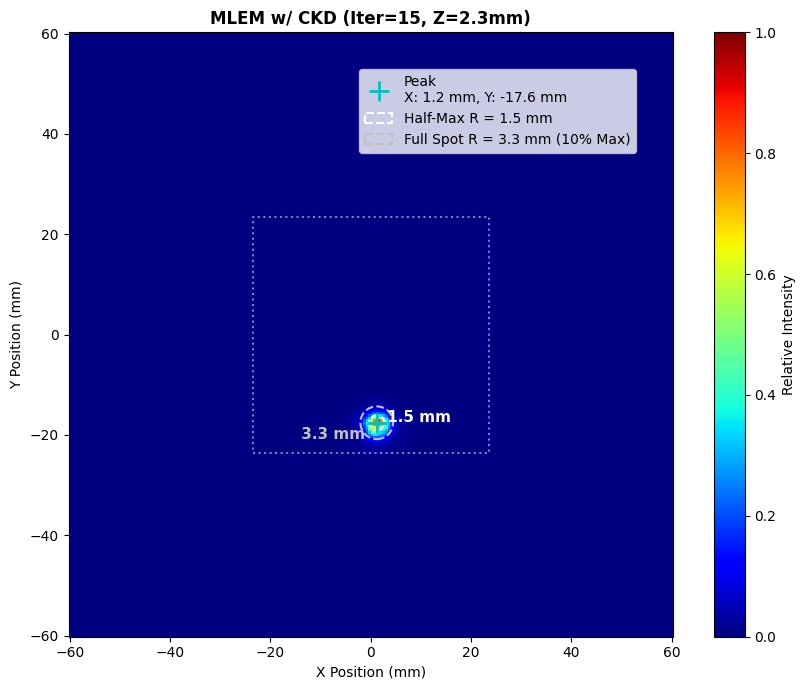

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches  # 用于绘制圆形
import time

m_e = 0.511  # 电子静止质量 MeV

def reconstruct_mlem_v3(df, Z_plane=50.0, resolution=200, fov=60.0, num_events=500, 
                        energy_window=(0.60, 0.72), iterations=10, sigma_deg=3.0,
                        ckd_ref_pos=(0.0, 0.0, 50.0)):
    """
    带有 CKD (运动学序列判别) 的 List-Mode MLEM 图像重建
    
    新增参数:
    - ckd_ref_pos: 用于 CKD 最小 ARM 判别的参考源位置，默认 (0,0,Z_plane)
    """
    
    print("1. 正在提取和筛选康普顿事件 (使用 CKD 序列判别)...")
    r1_positions, axes, angles = [], [], []
    ref_src = np.array(ckd_ref_pos)
    
    n_total = 0
    n_ckd_flipped = 0
    
    # 内部辅助函数：计算给定序列的 ARM 用于判别
    def get_kinematics(pos1, pos2, E_scattered, E_tot):
        cos_meas = 1 - m_e * (1 / E_scattered - 1 / E_tot)
        if not (-1 <= cos_meas <= 1): return None, None
        theta_meas = np.degrees(np.arccos(cos_meas))
        
        vec_in  = pos1 - ref_src
        vec_out = pos2 - pos1
        n_in  = np.linalg.norm(vec_in)
        n_out = np.linalg.norm(vec_out)
        if n_in == 0 or n_out == 0: return None, None
        cos_geo = np.clip(np.dot(vec_in, vec_out) / (n_in * n_out), -1.0, 1.0)
        theta_geo = np.degrees(np.arccos(cos_geo))
        
        return theta_meas, theta_meas - theta_geo

    # 提取并计算物理参量
    for row in df.itertuples(index=False):
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((np.array([getattr(row, f'{ch}_x'), 
                                           getattr(row, f'{ch}_y'), 
                                           getattr(row, f'{ch}_z')]), e_val))
                    
        if len(hits) != 2:
            continue
            
        E_total = hits[0][1] + hits[1][1]
        if not (energy_window[0] <= E_total <= energy_window[1]):
            continue
            
        n_total += 1
        posA, EA = hits[0][0], hits[0][1]
        posB, EB = hits[1][0], hits[1][1]
        
        # -------- CKD: 尝试两种散射序列 --------
        # 序列 1: A -> B (吸收点在 B，能量为 EB)
        theta_meas_1, arm_1 = get_kinematics(posA, posB, EB, E_total)
        # 序列 2: B -> A (吸收点在 A，能量为 EA)
        theta_meas_2, arm_2 = get_kinematics(posB, posA, EA, E_total)
        
        valid_seqs = []
        if arm_1 is not None: valid_seqs.append((abs(arm_1), posA, posB, theta_meas_1, posA[2] > posB[2]))
        if arm_2 is not None: valid_seqs.append((abs(arm_2), posB, posA, theta_meas_2, posB[2] > posA[2]))
        
        if not valid_seqs:
            continue
            
        # 选择 |ARM| 最小的序列作为真实物理序列
        valid_seqs.sort(key=lambda x: x[0])
        best_abs_arm, pos1, pos2, theta_meas_deg, is_z_descending = valid_seqs[0]
        
        # 统计被 CKD 纠正的序列（如果不按 Z 降序，说明原始简单粗暴的方法会排错）
        if not is_z_descending:
            n_ckd_flipped += 1
        
        # 计算 MLEM 投影所需的圆锥轴线
        vec = pos1 - pos2
        norm = np.linalg.norm(vec)
        if norm == 0: continue
        axis = vec / norm
        
        r1_positions.append(pos1)
        axes.append(axis)
        angles.append(np.radians(theta_meas_deg)) # MLEM 计算需要使用弧度

    plot_num = min(len(axes), num_events)
    if plot_num == 0:
        print("❌ 错误：没有提取到任何有效事件，请检查 final_df 数据格式或能量窗！")
        return
        
    print(f"✅ 成功提取 {len(axes)} 个有效事件 (将使用前 {plot_num} 个进行重建)。")
    print(f"   🔄 CKD 算法纠正了 {n_ckd_flipped} 个事件的顺序。")

    print(f"2. 初始化 Z = {Z_plane} mm 平面网格...")
    X = np.linspace(-fov, fov, resolution)
    Y = np.linspace(-fov, fov, resolution)
    XX, YY = np.meshgrid(X, Y)
    grid_points = np.stack((XX.flatten(), YY.flatten(), np.full_like(XX.flatten(), Z_plane)), axis=1)
    
    # 初始化图像为均匀分布
    image_mlem = np.ones(len(grid_points)) 
    sigma_rad = np.radians(sigma_deg)

    print(f"3. 开始 List-Mode MLEM 迭代 ({iterations} 次)...")
    start_time = time.time()
    
    for it in range(iterations):
        update_factor = np.zeros(len(grid_points))
        valid_events_this_iter = 0
        
        for i in range(plot_num):
            v_pixel = grid_points - r1_positions[i]
            v_pixel_norms = np.linalg.norm(v_pixel, axis=1) + 1e-10 # 防除零
            
            cos_alpha = np.sum(v_pixel * axes[i], axis=1) / v_pixel_norms
            cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
            alpha = np.arccos(cos_alpha)
            
            # 高斯概率响应
            t_i = np.exp(-0.5 * ((alpha - angles[i]) / sigma_rad)**2)
            t_i[t_i < 1e-3] = 0.0 # 截断极小值，加速且防噪
            
            # 投影期望值 F_i
            F_i = np.sum(t_i * image_mlem)
            
            # 累加更新因子 (只有 F_i 足够大时才更新)
            if F_i > 1e-12:
                update_factor += t_i / F_i
                valid_events_this_iter += 1
                
        # 纯净版 MLEM 更新公式
        image_mlem = image_mlem * update_factor
        
        # 打印监控
        max_val = np.max(image_mlem)
        print(f"   - 迭代 {it + 1}/{iterations} | 参与事件: {valid_events_this_iter}/{plot_num} | 图像峰值: {max_val:.2e}")

    print(f"迭代完成，耗时: {time.time() - start_time:.2f} 秒")
    
    print("正在裁切边界区...")
    x_mask = np.abs(grid_points[:, 0]) > 45
    y_mask = np.abs(grid_points[:, 1]) > 45
    image_mlem[x_mask | y_mask] = 0.0

    print("4. 绘制 MLEM 重建结果并计算光斑半径...")
    image_2d = image_mlem.reshape((resolution, resolution))
    
    # 归一化显示
    image_2d = image_2d / np.max(image_2d) 
    
    max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    peak_x, peak_y = X[max_idx[1]], Y[max_idx[0]]

    # ==========================
    # 计算亮斑半径 (等效面积法)
    # ==========================
    dx = X[1] - X[0]
    dy = Y[1] - Y[0]
    pixel_area = dx * dy
    
    # 1. 半峰值半径 (>= 50% 强度的等效面积)
    area_half = np.sum(image_2d >= 0.5) * pixel_area
    r_half = np.sqrt(area_half / np.pi)
    
    # 2. 整个亮斑半径 (使用 >= 10% 强度作为有效边界)
    area_full = np.sum(image_2d >= 0.1) * pixel_area
    r_full = np.sqrt(area_full / np.pi)

    # ==========================
    # 开始绘图
    # ==========================
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
    
    # 标记重建中心点
    ax.plot(peak_x, peak_y, 'c+', markersize=15, markeredgewidth=2, 
            label=f'Peak\nX: {peak_x:.1f} mm, Y: {peak_y:.1f} mm')
    
    # 绘制半峰值半径 (白色虚线)
    circle_half = patches.Circle((peak_x, peak_y), r_half, edgecolor='white', 
                                 facecolor='none', linestyle='--', linewidth=1.5,
                                 label=f'Half-Max R = {r_half:.1f} mm')
    ax.add_patch(circle_half)
    
    # 绘制全亮斑半径 (灰色虚线)
    circle_full = patches.Circle((peak_x, peak_y), r_full, edgecolor='silver', 
                                 facecolor='none', linestyle='--', linewidth=1.5,
                                 label=f'Full Spot R = {r_full:.1f} mm (10% Max)')
    ax.add_patch(circle_full)

    # 在图像上直接添加文本标注数值 (利用 45 度角的三角函数错开位置，防遮挡)
    ax.text(peak_x + r_half * 0.7, peak_y + r_half * 0.7, f' {r_half:.1f} mm', 
            color='white', fontsize=11, fontweight='bold', va='center')
    ax.text(peak_x - r_full * 0.7, peak_y - r_full * 0.7, f' {r_full:.1f} mm', 
            color='silver', fontsize=11, fontweight='bold', va='center', ha='right')
    
    ax.set_title(f"MLEM w/ CKD (Iter={iterations}, Z={Z_plane}mm)", fontweight='bold')
    ax.set_xlabel("X Position (mm)")
    ax.set_ylabel("Y Position (mm)")
    fig.colorbar(im, ax=ax, label='Relative Intensity')
    ax.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
    
    # 绘制探测器的物理边界参考框 (47mm x 47mm)
    det_size = 14 * 3.36 / 2
    ax.plot([-det_size, det_size, det_size, -det_size, -det_size], 
            [-det_size, -det_size, det_size, det_size, -det_size], 
            'w:', alpha=0.5, label='Detector FOV')
    
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

# ================= 调用示例 =================
if __name__ == "__main__":
    # 填入之前高斯拟合的最佳 Sigma 值
    best_sigma = 11.06 
    
    reconstruct_mlem_v3(
        df=final_df, 
        Z_plane=2.3,            
        resolution=250,          
        fov=60.0,                
        num_events=100000,         
        energy_window=(0.652, 0.672), 
        iterations=15,           
        sigma_deg=best_sigma,
        ckd_ref_pos=(1.7, -18.1, 2.3) # 使用大致的源坐标来帮助 CKD 正确判断散射序列
    )

1. 正在提取和筛选康普顿事件...
✅ 成功提取 25652 个有效事件。
2. 初始化 Z = 10.0 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 24992/25652 | 图像峰值: 1.63e+00
   - 迭代 2/15 | 参与事件: 24992/25652 | 图像峰值: 4.33e+00
   - 迭代 3/15 | 参与事件: 24992/25652 | 图像峰值: 9.18e+00
   - 迭代 4/15 | 参与事件: 24992/25652 | 图像峰值: 1.66e+01
   - 迭代 5/15 | 参与事件: 24992/25652 | 图像峰值: 2.66e+01
   - 迭代 6/15 | 参与事件: 24992/25652 | 图像峰值: 3.84e+01
   - 迭代 7/15 | 参与事件: 24992/25652 | 图像峰值: 5.09e+01
   - 迭代 8/15 | 参与事件: 24992/25652 | 图像峰值: 6.32e+01
   - 迭代 9/15 | 参与事件: 24992/25652 | 图像峰值: 7.49e+01
   - 迭代 10/15 | 参与事件: 24992/25652 | 图像峰值: 8.56e+01
   - 迭代 11/15 | 参与事件: 24992/25652 | 图像峰值: 9.54e+01
   - 迭代 12/15 | 参与事件: 24992/25652 | 图像峰值: 1.04e+02
   - 迭代 13/15 | 参与事件: 24992/25652 | 图像峰值: 1.12e+02
   - 迭代 14/15 | 参与事件: 24992/25652 | 图像峰值: 1.20e+02
   - 迭代 15/15 | 参与事件: 24992/25652 | 图像峰值: 1.27e+02
迭代完成，耗时: 2973.44 秒
迭代完成，正在裁切边界区...
4. 绘制 MLEM 重建结果并计算光斑半径...


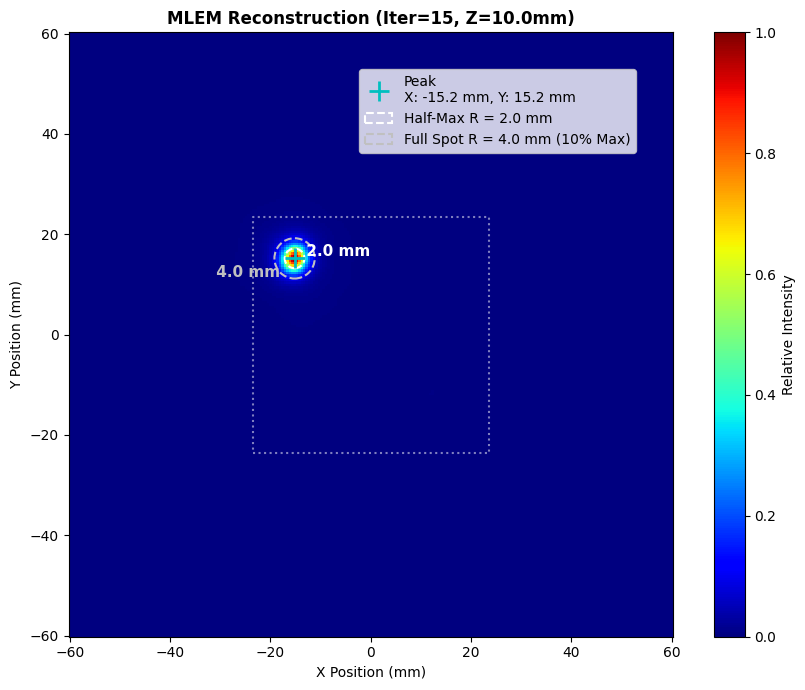

1. 正在提取和筛选康普顿事件...
✅ 成功提取 25652 个有效事件。
2. 初始化 Z = 10.0 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 25105/25652 | 图像峰值: 1.49e+00
   - 迭代 2/15 | 参与事件: 25105/25652 | 图像峰值: 3.78e+00
   - 迭代 3/15 | 参与事件: 25105/25652 | 图像峰值: 7.79e+00
   - 迭代 4/15 | 参与事件: 25105/25652 | 图像峰值: 1.39e+01
   - 迭代 5/15 | 参与事件: 25105/25652 | 图像峰值: 2.22e+01
   - 迭代 6/15 | 参与事件: 25105/25652 | 图像峰值: 3.23e+01
   - 迭代 7/15 | 参与事件: 25105/25652 | 图像峰值: 4.35e+01
   - 迭代 8/15 | 参与事件: 25105/25652 | 图像峰值: 5.49e+01
   - 迭代 9/15 | 参与事件: 25105/25652 | 图像峰值: 6.62e+01
   - 迭代 10/15 | 参与事件: 25105/25652 | 图像峰值: 7.68e+01
   - 迭代 11/15 | 参与事件: 25105/25652 | 图像峰值: 8.68e+01
   - 迭代 12/15 | 参与事件: 25105/25652 | 图像峰值: 9.60e+01
   - 迭代 13/15 | 参与事件: 25105/25652 | 图像峰值: 1.05e+02
   - 迭代 14/15 | 参与事件: 25105/25652 | 图像峰值: 1.12e+02
   - 迭代 15/15 | 参与事件: 25105/25652 | 图像峰值: 1.20e+02
迭代完成，耗时: 2953.41 秒
迭代完成，正在裁切边界区...
4. 绘制 MLEM 重建结果并计算光斑半径...


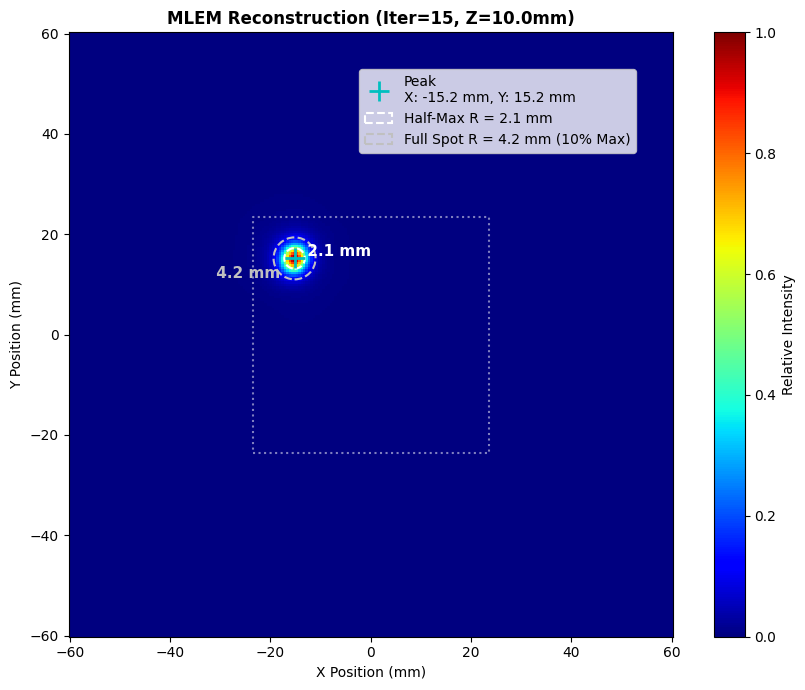

1. 正在提取和筛选康普顿事件...
✅ 成功提取 25652 个有效事件。
2. 初始化 Z = 10.0 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 25188/25652 | 图像峰值: 1.37e+00
   - 迭代 2/15 | 参与事件: 25188/25652 | 图像峰值: 3.31e+00
   - 迭代 3/15 | 参与事件: 25188/25652 | 图像峰值: 6.60e+00
   - 迭代 4/15 | 参与事件: 25188/25652 | 图像峰值: 1.16e+01
   - 迭代 5/15 | 参与事件: 25188/25652 | 图像峰值: 1.84e+01
   - 迭代 6/15 | 参与事件: 25188/25652 | 图像峰值: 2.69e+01
   - 迭代 7/15 | 参与事件: 25188/25652 | 图像峰值: 3.66e+01
   - 迭代 8/15 | 参与事件: 25188/25652 | 图像峰值: 4.69e+01
   - 迭代 9/15 | 参与事件: 25188/25652 | 图像峰值: 5.72e+01
   - 迭代 10/15 | 参与事件: 25188/25652 | 图像峰值: 6.74e+01
   - 迭代 11/15 | 参与事件: 25188/25652 | 图像峰值: 7.71e+01
   - 迭代 12/15 | 参与事件: 25188/25652 | 图像峰值: 8.62e+01
   - 迭代 13/15 | 参与事件: 25188/25652 | 图像峰值: 9.48e+01
   - 迭代 14/15 | 参与事件: 25188/25652 | 图像峰值: 1.03e+02
   - 迭代 15/15 | 参与事件: 25188/25652 | 图像峰值: 1.10e+02
迭代完成，耗时: 2952.94 秒
迭代完成，正在裁切边界区...
4. 绘制 MLEM 重建结果并计算光斑半径...


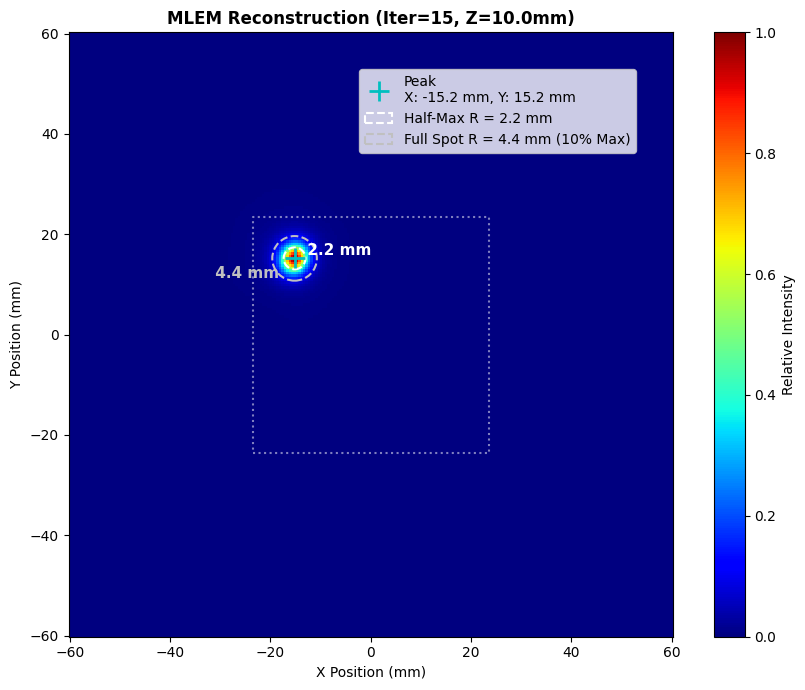

1. 正在提取和筛选康普顿事件...
✅ 成功提取 25652 个有效事件。
2. 初始化 Z = 10.0 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 25287/25652 | 图像峰值: 1.27e+00
   - 迭代 2/15 | 参与事件: 25287/25652 | 图像峰值: 2.89e+00
   - 迭代 3/15 | 参与事件: 25287/25652 | 图像峰值: 5.60e+00
   - 迭代 4/15 | 参与事件: 25287/25652 | 图像峰值: 9.65e+00
   - 迭代 5/15 | 参与事件: 25287/25652 | 图像峰值: 1.52e+01
   - 迭代 6/15 | 参与事件: 25287/25652 | 图像峰值: 2.22e+01
   - 迭代 7/15 | 参与事件: 25287/25652 | 图像峰值: 3.04e+01
   - 迭代 8/15 | 参与事件: 25287/25652 | 图像峰值: 3.94e+01
   - 迭代 9/15 | 参与事件: 25287/25652 | 图像峰值: 4.87e+01
   - 迭代 10/15 | 参与事件: 25287/25652 | 图像峰值: 5.81e+01
   - 迭代 11/15 | 参与事件: 25287/25652 | 图像峰值: 6.72e+01
   - 迭代 12/15 | 参与事件: 25287/25652 | 图像峰值: 7.60e+01
   - 迭代 13/15 | 参与事件: 25287/25652 | 图像峰值: 8.44e+01
   - 迭代 14/15 | 参与事件: 25287/25652 | 图像峰值: 9.23e+01
   - 迭代 15/15 | 参与事件: 25287/25652 | 图像峰值: 9.99e+01
迭代完成，耗时: 3022.76 秒
迭代完成，正在裁切边界区...
4. 绘制 MLEM 重建结果并计算光斑半径...


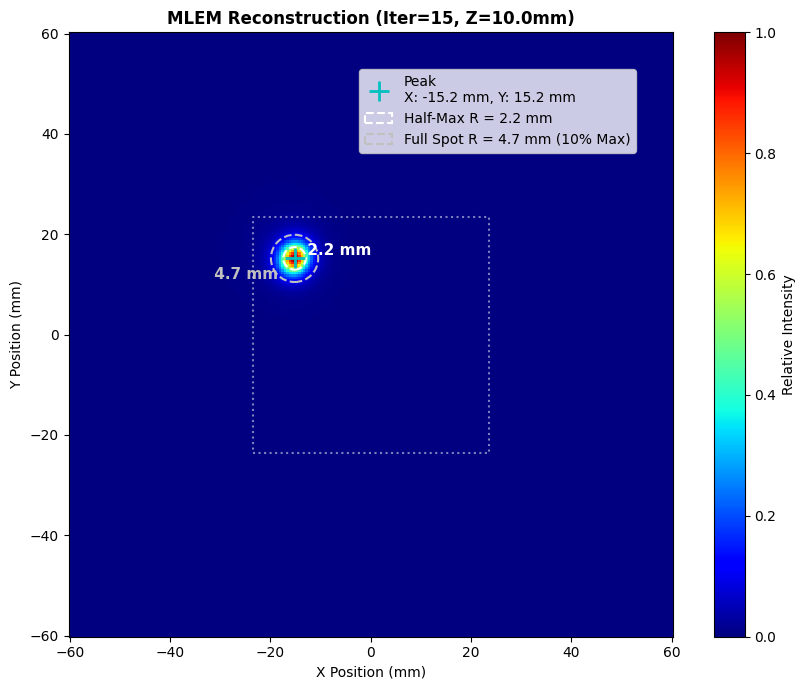

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches  # 新增：用于绘制圆形
import time

m_e = 0.511  # 电子静止质量 MeV

def reconstruct_mlem_v3(df, Z_plane=50.0, resolution=200, fov=60.0, num_events=500, 
                        energy_window=(0.60, 0.72), iterations=10, sigma_deg=3.0):
    
    print("1. 正在提取和筛选康普顿事件...")
    r1_positions, axes, angles = [], [], []
    
    # 提取并计算物理参量
    for row in df.itertuples(index=False):
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
        if len(hits) != 2:
            continue
            
        E_total = sum(h[3] for h in hits)
        if not (energy_window[0] <= E_total <= energy_window[1]):
            continue
            
        # 按照 Z 坐标降序排列，确保物理因果律 (假设源在正前方 Z > 0)
        hits.sort(key=lambda item: item[2], reverse=True)
        p1, p2 = hits[0], hits[1]
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        
        E2_total = p2[3] 
        
        vec = pos1 - pos2
        norm = np.linalg.norm(vec)
        if norm == 0: continue
        axis = vec / norm
        
        cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
        if -1 <= cos_theta <= 1:
            r1_positions.append(pos1)
            axes.append(axis)
            angles.append(np.arccos(cos_theta))

    plot_num = min(len(axes), num_events)
    if plot_num == 0:
        print("❌ 错误：没有提取到任何有效事件，请检查 final_df 数据格式或能量窗！")
        return
        
    print(f"✅ 成功提取 {plot_num} 个有效事件。")

    print(f"2. 初始化 Z = {Z_plane} mm 平面网格...")
    X = np.linspace(-fov, fov, resolution)
    Y = np.linspace(-fov, fov, resolution)
    XX, YY = np.meshgrid(X, Y)
    grid_points = np.stack((XX.flatten(), YY.flatten(), np.full_like(XX.flatten(), Z_plane)), axis=1)
    
    # 初始化图像为均匀分布
    image_mlem = np.ones(len(grid_points)) 
    sigma_rad = np.radians(sigma_deg)

    print(f"3. 开始 List-Mode MLEM 迭代 ({iterations} 次)...")
    start_time = time.time()
    
    for it in range(iterations):
        update_factor = np.zeros(len(grid_points))
        valid_events_this_iter = 0
        
        for i in range(plot_num):
            v_pixel = grid_points - r1_positions[i]
            v_pixel_norms = np.linalg.norm(v_pixel, axis=1) + 1e-10 # 防除零
            
            cos_alpha = np.sum(v_pixel * axes[i], axis=1) / v_pixel_norms
            cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
            alpha = np.arccos(cos_alpha)
            
            # 高斯概率响应
            t_i = np.exp(-0.5 * ((alpha - angles[i]) / sigma_rad)**2)
            t_i[t_i < 1e-3] = 0.0 # 截断极小值，加速且防噪
            
            # 投影期望值 F_i
            F_i = np.sum(t_i * image_mlem)
            
            # 累加更新因子 (只有 F_i 足够大时才更新)
            if F_i > 1e-12:
                update_factor += t_i / F_i
                valid_events_this_iter += 1
                
        # 纯净版 MLEM 更新公式
        image_mlem = image_mlem * update_factor
        
        # 打印监控
        max_val = np.max(image_mlem)
        print(f"   - 迭代 {it + 1}/{iterations} | 参与事件: {valid_events_this_iter}/{plot_num} | 图像峰值: {max_val:.2e}")

    print(f"迭代完成，耗时: {time.time() - start_time:.2f} 秒")
    
    print("迭代完成，正在裁切边界区...")
    x_mask = np.abs(grid_points[:, 0]) > 45
    y_mask = np.abs(grid_points[:, 1]) > 45
    image_mlem[x_mask | y_mask] = 0.0

    print("4. 绘制 MLEM 重建结果并计算光斑半径...")
    image_2d = image_mlem.reshape((resolution, resolution))
    
    # 归一化显示
    image_2d = image_2d / np.max(image_2d) 
    
    max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    peak_x, peak_y = X[max_idx[1]], Y[max_idx[0]]

    # ==========================
    # 计算亮斑半径 (等效面积法)
    # ==========================
    dx = X[1] - X[0]
    dy = Y[1] - Y[0]
    pixel_area = dx * dy
    
    # 1. 半峰值半径 (>= 50% 强度的等效面积)
    area_half = np.sum(image_2d >= 0.5) * pixel_area
    r_half = np.sqrt(area_half / np.pi)
    
    # 2. 整个亮斑半径 (使用 >= 10% 强度作为有效边界)
    area_full = np.sum(image_2d >= 0.1) * pixel_area
    r_full = np.sqrt(area_full / np.pi)

    # ==========================
    # 开始绘图
    # ==========================
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
    
    # 标记重建中心点
    ax.plot(peak_x, peak_y, 'c+', markersize=15, markeredgewidth=2, 
            label=f'Peak\nX: {peak_x:.1f} mm, Y: {peak_y:.1f} mm')
    
    # 绘制半峰值半径 (白色虚线)
    circle_half = patches.Circle((peak_x, peak_y), r_half, edgecolor='white', 
                                 facecolor='none', linestyle='--', linewidth=1.5,
                                 label=f'Half-Max R = {r_half:.1f} mm')
    ax.add_patch(circle_half)
    
    # 绘制全亮斑半径 (灰色虚线)
    circle_full = patches.Circle((peak_x, peak_y), r_full, edgecolor='silver', 
                                 facecolor='none', linestyle='--', linewidth=1.5,
                                 label=f'Full Spot R = {r_full:.1f} mm (10% Max)')
    ax.add_patch(circle_full)

    # 在图像上直接添加文本标注数值 (利用 45 度角的三角函数错开位置，防遮挡)
    ax.text(peak_x + r_half * 0.7, peak_y + r_half * 0.7, f' {r_half:.1f} mm', 
            color='white', fontsize=11, fontweight='bold', va='center')
    ax.text(peak_x - r_full * 0.7, peak_y - r_full * 0.7, f' {r_full:.1f} mm', 
            color='silver', fontsize=11, fontweight='bold', va='center', ha='right')
    
    ax.set_title(f"MLEM Reconstruction (Iter={iterations}, Z={Z_plane}mm)", fontweight='bold')
    ax.set_xlabel("X Position (mm)")
    ax.set_ylabel("Y Position (mm)")
    fig.colorbar(im, ax=ax, label='Relative Intensity')
    ax.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
    
    # 绘制探测器的物理边界参考框 (47mm x 47mm)
    det_size = 14 * 3.36 / 2
    ax.plot([-det_size, det_size, det_size, -det_size, -det_size], 
            [-det_size, -det_size, det_size, det_size, -det_size], 
            'w:', alpha=0.5, label='Detector FOV')
    
    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

# 调用示例
if __name__ == "__main__":
    # 假设你已经有了 final_df 数据
    for sigma in [7, 8, 9,10]:
        reconstruct_mlem_v3(
            df=final_df, 
            Z_plane=10.0,            
            resolution=250,          
            fov=60.0,                
            num_events=100000,         
            energy_window=(0.652, 0.672), 
            iterations=15,           
            sigma_deg=sigma          
        )

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import time

# m_e = 0.511  # 电子静止质量 MeV

# def reconstruct_mlem_v3(df, Z_plane=50.0, resolution=200, fov=60.0, num_events=500, 
#                         energy_window=(0.60, 0.72), iterations=10, sigma_deg=3.0):
    
#     print("1. 正在提取和筛选康普顿事件...")
#     r1_positions, axes, angles = [], [], []
    
#     # 提取并计算物理参量
#     for row in df.itertuples(index=False):
#         hits = []
#         for ch in ['ch0', 'ch1', 'ch2']:
#             e_col = f'{ch}_energy'
#             if hasattr(row, e_col):
#                 e_val = getattr(row, e_col)
#                 if pd.notna(e_val) and e_val > 0:
#                     hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
#         if len(hits) != 2:
#             continue
            
#         E_total = sum(h[3] for h in hits)
#         if not (energy_window[0] <= E_total <= energy_window[1]):
#             continue
            
#         # 按照 Z 坐标降序排列，确保物理因果律 (假设源在正前方 Z > 0)
#         hits.sort(key=lambda item: item[2], reverse=True)
#         p1, p2 = hits[0], hits[1]
        
#         pos1 = np.array([p1[0], p1[1], p1[2]])
#         pos2 = np.array([p2[0], p2[1], p2[2]])
        
#         E2_total = p2[3] 
        
#         vec = pos1 - pos2
#         norm = np.linalg.norm(vec)
#         if norm == 0: continue
#         axis = vec / norm
        
#         cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
#         if -1 <= cos_theta <= 1:
#             r1_positions.append(pos1)
#             axes.append(axis)
#             angles.append(np.arccos(cos_theta))

#     plot_num = min(len(axes), num_events)
#     if plot_num == 0:
#         print("❌ 错误：没有提取到任何有效事件，请检查 final_df 数据格式或能量窗！")
#         return
        
#     print(f"✅ 成功提取 {plot_num} 个有效事件。")

#     print(f"2. 初始化 Z = {Z_plane} mm 平面网格...")
#     X = np.linspace(-fov, fov, resolution)
#     Y = np.linspace(-fov, fov, resolution)
#     XX, YY = np.meshgrid(X, Y)
#     grid_points = np.stack((XX.flatten(), YY.flatten(), np.full_like(XX.flatten(), Z_plane)), axis=1)
    
#     # 初始化图像为均匀分布
#     image_mlem = np.ones(len(grid_points)) 
#     sigma_rad = np.radians(sigma_deg)

#     print(f"3. 开始 List-Mode MLEM 迭代 ({iterations} 次)...")
#     start_time = time.time()
    
#     for it in range(iterations):
#         update_factor = np.zeros(len(grid_points))
#         valid_events_this_iter = 0
        
#         for i in range(plot_num):
#             v_pixel = grid_points - r1_positions[i]
#             v_pixel_norms = np.linalg.norm(v_pixel, axis=1) + 1e-10 # 防除零
            
#             cos_alpha = np.sum(v_pixel * axes[i], axis=1) / v_pixel_norms
#             cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
#             alpha = np.arccos(cos_alpha)
            
#             # 高斯概率响应
#             t_i = np.exp(-0.5 * ((alpha - angles[i]) / sigma_rad)**2)
#             t_i[t_i < 1e-3] = 0.0 # 截断极小值，加速且防噪
            
#             # 投影期望值 F_i
#             F_i = np.sum(t_i * image_mlem)
            
#             # 累加更新因子 (只有 F_i 足够大时才更新)
#             if F_i > 1e-12:
#                 update_factor += t_i / F_i
#                 valid_events_this_iter += 1
                
#         # 纯净版 MLEM 更新公式 (移除错误的自身敏感度惩罚)
#         image_mlem = image_mlem * update_factor
        
#         # 打印监控
#         max_val = np.max(image_mlem)
#         print(f"   - 迭代 {it + 1}/{iterations} | 参与事件: {valid_events_this_iter}/{plot_num} | 图像峰值: {max_val:.2e}")

#     print(f"迭代完成，耗时: {time.time() - start_time:.2f} 秒")

#     print("4. 绘制 MLEM 重建结果...")
#     image_2d = image_mlem.reshape((resolution, resolution))
    
#     # 归一化显示
#     image_2d = image_2d / np.max(image_2d) 
    
#     max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
#     peak_x, peak_y = X[max_idx[1]], Y[max_idx[0]]

#     plt.figure(figsize=(9, 7))
#     # 推荐使用 'hot' 或 'jet'，'hot' 对高亮点的对比度更好
#     im = plt.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
#     plt.plot(peak_x, peak_y, 'c+', markersize=20, markeredgewidth=2, 
#              label=f'Reconstructed Source\nX: {peak_x:.1f} mm, Y: {peak_y:.1f} mm')
    
#     plt.title(f"MLEM Reconstruction (Iter={iterations}, Z={Z_plane}mm)", fontweight='bold')
#     plt.xlabel("X Position (mm)")
#     plt.ylabel("Y Position (mm)")
#     plt.colorbar(im, label='Relative Intensity')
#     plt.legend(loc='upper right')
    
#     # 绘制探测器的物理边界参考框 (47mm x 47mm)
#     det_size = 14 * 3.36 / 2
#     plt.plot([-det_size, det_size, det_size, -det_size, -det_size], 
#              [-det_size, -det_size, det_size, det_size, -det_size], 
#              'w--', alpha=0.5, label='Detector FOV (47x47mm)')
    
#     plt.gca().set_aspect('equal', adjustable='box')
#     plt.tight_layout()
#     plt.show()

# # 调用示例
# if __name__ == "__main__":
#     # 假设你已经有了 final_df 数据
#     for z in range(25,26,1):
#         reconstruct_mlem_v3(
#             df=final_df, 
#             Z_plane=z,            # 请确保这是真实的放射源 Z 距离
#             resolution=250,          # 提高分辨率让图像更平滑
#             fov=60.0,                # 探测器本身只有 47x47mm，FOV 设为 60 足够覆盖全貌
#             num_events=100000,         # 增加事件数以提高信噪比
#             energy_window=(0.652, 0.672), 
#             iterations=15,           # 强烈建议迭代 10 - 15 次，效果最佳
#             sigma_deg=2.5            # 适配 3.36mm 像素的高斯平滑度 (推荐 2.5 ~ 3.5 之间微调)
#         )